# Menentukan Pertanyaan Bisnis

1. Berapa nilai probabilitas sebagai ambang batas (*threshold*) untuk memicu intervensi sistem selama proses pengerjaan kuis?
2. Apakah model menunjukkan bias pada kelompok siswa tertentu berdasarkan pola performa atau karakteristik pembelajaran?
3. Apakah intervensi pembelajaran yang difokuskan pada materi dengan probabilitas penguasaan terendah lebih efektif dalam meningkatkan performa siswa dibandingkan strategi lainnya?
4. Bagaimana pengaruh intervensi adaptif yang diberikan di tengah kuis terhadap nilai performa akhir siswa?
5. Bagaimana skema kelanjutan sesi kuis setelah intervensi (melanjutkan atau mengulang) mempengaruhi hasil evaluasi dan pengalaman belajar siswa?
6. Bagaimana pemanfaatan data historis sesi sebelumnya (pre-intervention) mempengaruhi akurasi prediksi dan evaluasi performa siswa?
7. Seberapa cepat sistem dapat menghasilkan prediksi dan memberikan intervensi secara real-time tanpa mengganggu pengalaman pengguna?



# Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data Wrangling

## Gathering Data

Dataset "ASSISTments 2009-2010 Skill Builder" adalah kumpulan data interaksi belajar siswa secara real-time di platform pembelajaran matematika ASSISTments. Dataset ini dirancang untuk memodelkan lintasan pembelajaran siswa (learning trajectories) dan memprediksi penguasaan konsep (knowledge tracing) berdasarkan riwayat jawaban mereka.

Dataset ini berisi lebih dari 500.000 baris log interaksi dari ribuan siswa. Fokus utamanya adalah merekam urutan jawaban benar/salah siswa terhadap berbagai konsep matematika untuk melihat bagaimana kemampuan siswa berkembang dari waktu ke waktu.

Berikut adalah rincian kolom-kolom kunci yang akan kita gunakan:

**Identitas Siswa & Konteks**

*   order_id: Identitas unik untuk setiap transaksi/jawaban. Berperan sebagai penanda urutan kronologis interaksi (sangat penting untuk model time-series).
*   user_id: Identitas unik untuk setiap siswa. Digunakan untuk mengelompokkan data berdasarkan individu agar tidak terjadi data leakage saat pembagian data train dan test.
*   assignment_id: Identitas tugas atau paket soal yang dikerjakan siswa.
*   problem_id: Identitas spesifik untuk setiap butir soal matematika.

**Identitas Konsep**
*   skill_id: Identitas unik untuk konsep matematika tertentu (misalnya: perkalian, aljabar, dsb). Ini adalah variabel kunci untuk memetakan keahlian mana yang sedang dipelajari.
*   skill_name: Nama atau deskripsi tekstual dari konsep tersebut. Membantu dalam tahap EDA untuk memberikan konteks pada visualisasi konsep tersulit.

**Metrik Performa & Interaksi**
*   correct: Indikator keberhasilan siswa pada percobaan pertama (1 = Benar, 0 = Salah atau minta bantuan). Ini adalah variabel target utama dalam model prediksi kita. Nilai correct=0 tidak selalu berarti jawaban salah murni. Bisa juga karena siswa menggunakan hint, yang secara otomatis ditandai incorrect oleh sistem ASSISTments.
*   attempt_count: Jumlah percobaan yang dilakukan siswa pada soal yang sama. Nilai >1 menandakan siswa mengulang soal yang sama, yang bisa jadi indikator kesulitan.
*   ms_first_response: Waktu yang dibutuhkan siswa (dalam milidetik) untuk memberikan jawaban pertama. Digunakan untuk menganalisis kecepatan berpikir dan mendeteksi perilaku tebak-tebakan (guessing).
*   hint_count: Jumlah bantuan/petunjuk (hint) yang dipanggil oleh siswa. Berkorelasi kuat dengan tingkat beban kognitif dan kesulitan materi.
*   first_action: Mencatat aksi pertama yang dilakukan siswa saat mengerjakan soal, apakah langsung menjawab atau langsung minta hint. Ini bisa jadi fitur tambahan untuk analisis behavior siswa di EDA.

**Atribut Pendukung**
*   original: Menunjukkan apakah soal tersebut adalah soal asli (1) atau soal bantuan/perancah (0).
*   opportunity: Urutan keberapa siswa tersebut bertemu dengan konsep (skill_id) yang sama. Variabel ini sangat berguna untuk melihat learning progression (semakin sering bertemu, seharusnya probabilitas benar semakin tinggi).
*   overlap_time: Waktu tumpang tindih antar sesi pengerjaan. Berguna untuk deteksi anomali sesi yang tidak wajar, misalnya siswa yang mengerjakan soal dalam waktu yang tidak realistis.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

main_path = '/content/drive/MyDrive/Data_Project_Dicoding/skill_builder_data_corrected_collapsed.csv'
df = pd.read_csv(main_path, encoding='ISO-8859-1')

reference_path = '/content/drive/MyDrive/Data_Project_Dicoding/skill_builder_data.csv'
df_reference = pd.read_csv(reference_path,encoding='ISO-8859-1')

print("Main dataset shape:")
print(df.shape)

print("\nReference dataset shape:")
print(df_reference.shape)

display(df.head())

Mounted at /content/drive


/tmp/ipykernel_2782/3975896464.py:5: DtypeWarning: Columns (17,18) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(main_path, encoding='ISO-8859-1')
/tmp/ipykernel_2782/3975896464.py:8: DtypeWarning: Columns (17) have mixed types. Specify dtype option on import or set low_memory=False.
  df_reference = pd.read_csv(reference_path,encoding='ISO-8859-1')


Main dataset shape:
(346860, 31)

Reference dataset shape:
(525534, 30)


,Unnamed: 0,order_id,assignment_id,user_id,assistment_id,problem_id,original,correct,attempt_count,ms_first_response,...,hint_count,hint_total,overlap_time,template_id,answer_id,answer_text,first_action,bottom_hint,opportunity,opportunity_original
0,1,33022537,277618,64525,33139,51424,1,1,1,32454,...,0,3,32454,30799,NaN,26,0,NaN,1,1.0
1,2,33022709,277618,64525,33150,51435,1,1,1,4922,...,0,3,4922,30799,NaN,55,0,NaN,2,2.0
2,3,35450204,220674,70363,33159,51444,1,0,2,25390,...,0,3,42000,30799,NaN,88,0,NaN,1,1.0
3,4,35450295,220674,70363,33110,51395,1,1,1,4859,...,0,3,4859,30059,NaN,41,0,NaN,2,2.0
4,5,35450311,220674,70363,33196,51481,1,0,14,19813,...,3,4,124564,30060,NaN,65,0,0.0,3,3.0


## Assesing Data

### Menghitung Dimensi Data

In [ ]:
print(f"Total baris data: {df.shape[0]}")
print(f"Total kolom data: {df.shape[1]}")
print("\nDaftar Kolom yang Tersedia:")
print(df.columns.tolist())

Total baris data: 346860
Total kolom data: 31

Daftar Kolom yang Tersedia:
['Unnamed: 0', 'order_id', 'assignment_id', 'user_id', 'assistment_id', 'problem_id', 'original', 'correct', 'attempt_count', 'ms_first_response', 'tutor_mode', 'answer_type', 'sequence_id', 'student_class_id', 'position', 'type', 'base_sequence_id', 'skill_id', 'skill_name', 'teacher_id', 'school_id', 'hint_count', 'hint_total', 'overlap_time', 'template_id', 'answer_id', 'answer_text', 'first_action', 'bottom_hint', 'opportunity', 'opportunity_original']


### Identifikasi Jenis Data

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 346860 entries, 0 to 346859
Data columns (total 31 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Unnamed: 0            346860 non-null  int64  
 1   order_id              346860 non-null  int64  
 2   assignment_id         346860 non-null  int64  
 3   user_id               346860 non-null  int64  
 4   assistment_id         346860 non-null  int64  
 5   problem_id            346860 non-null  int64  
 6   original              346860 non-null  int64  
 7   correct               346860 non-null  int64  
 8   attempt_count         346860 non-null  int64  
 9   ms_first_response     346860 non-null  int64  
 10  tutor_mode            346860 non-null  object 
 11  answer_type           346860 non-null  object 
 12  sequence_id           346860 non-null  int64  
 13  student_class_id      346860 non-null  int64  
 14  position              346860 non-null  int64  
 15  

### Menghitung Missing Value pada Data

In [ ]:
df.isna().sum()

,0
Unnamed: 0,0
order_id,0
assignment_id,0
user_id,0
assistment_id,0
problem_id,0
original,0
correct,0
attempt_count,0
ms_first_response,0


### Identifikasi Kolom Kritis

In [ ]:
kolom_kritis = ['user_id', 'skill_name', 'skill_id', 'correct', 'order_id']

for col in kolom_kritis:
    missing_n = df[col].isnull().sum()
    missing_p = missing_n / len(df) * 100
    unique_n  = df[col].nunique()
    status    = "OK" if missing_n == 0 else "ADA MISSING"

    print(f"\n[{status}] {col}")
    print(f"  Missing : {missing_n:,} ({missing_p:.2f}%)")
    print(f"  Unique  : {unique_n:,}")

    if col == 'correct':
        print(f"  Values  : {sorted(df[col].unique())}")
    if col == 'skill_id':
        print(f"  Sample  : {df[col].dropna().unique()[:5]}")
    if col == 'skill_name':
        print(f"  Sample  : {df[col].dropna().unique()[:5]}")


[OK] user_id
  Missing : 0 (0.00%)
  Unique  : 4,217

[ADA MISSING] skill_name
  Missing : 72,270 (20.84%)
  Unique  : 101
  Sample  : ['Box and Whisker' 'Circle Graph' 'Histogram as Table or Graph'
 'Number Line' 'Scatter Plot']

[ADA MISSING] skill_id
  Missing : 63,755 (18.38%)
  Unique  : 150
  Sample  : ['1_13' '1_15' '1' '2_37_70' '2_37_48_77']

[OK] correct
  Missing : 0 (0.00%)
  Unique  : 2
  Values  : [np.int64(0), np.int64(1)]

[OK] order_id
  Missing : 0 (0.00%)
  Unique  : 346,860


Berdasarkan hasil data assessment yang telah dilakukan sebelumnya, dari 31 kolom yang tersedia dalam dataset hanya sebagian kecil yang benar-benar relevan untuk keperluan analisis dan modeling. Oleh karena itu, dilakukan filtering kolom untuk memfokuskan analisis hanya pada kolom-kolom yang memiliki peran langsung dalam proses sequence construction, data cleaning, maupun exploratory data analysis. Hal ini dilakukan untuk membuat proses analisis lebih efisien, mengurangi noise dari kolom yang tidak relevan, serta memastikan bahwa setiap tahap berikutnya hanya bekerja dengan data yang benar-benar dibutuhkan.

In [ ]:
# Kolom yang dipertahankan
kolom_dipakai = [
    'order_id',
    'user_id',
    'skill_id',
    'skill_name',
    'correct',
    'hint_count',
    'original',
    'attempt_count',
    'ms_first_response',
    'opportunity'
]

# Filter dataframe
df_filtered = df[kolom_dipakai].copy()

print(f"\nShape sebelum filter kolom : {df.shape}")
print(f"Shape setelah filter kolom : {df_filtered.shape}")

print(f"\n{'=' * 50}")
print("KOLOM YANG DIPERTAHANKAN")
print("=" * 50)
print(df_filtered.info())

print(f"\n{'=' * 50}")
print("MISSING VALUES KOLOM TERPILIH")
print("=" * 50)
missing = df_filtered.isnull().sum()
missing_pct = (missing / len(df_filtered) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})
print(missing_df.to_string())


Shape sebelum filter kolom : (346860, 31)
Shape setelah filter kolom : (346860, 10)

KOLOM YANG DIPERTAHANKAN
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 346860 entries, 0 to 346859
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   order_id           346860 non-null  int64 
 1   user_id            346860 non-null  int64 
 2   skill_id           283105 non-null  object
 3   skill_name         274590 non-null  object
 4   correct            346860 non-null  int64 
 5   hint_count         346860 non-null  int64 
 6   original           346860 non-null  int64 
 7   attempt_count      346860 non-null  int64 
 8   ms_first_response  346860 non-null  int64 
 9   opportunity        346860 non-null  int64 
dtypes: int64(8), object(2)
memory usage: 26.5+ MB
None

MISSING VALUES KOLOM TERPILIH
                   Missing Count  Missing %
order_id                       0       0.00
user_id                    

**Insight**

**1. Struktur dan Dimensi Data**

Dataset ASSISTments 2009-2010 versi corrected memiliki 346.860 baris dan 31 kolom. Dataset mencakup 4.217 siswa unik dengan 346.860 interaksi unik yang masing-masing memiliki order_id berbeda. Total terdapat 101 skill matematika unik berdasarkan skill_name dan 150 entitas unik pada skill_id.

**2. Tipe Data dan Inkonsistensi**
*   skill_id: kolom ini bertipe object padahal seharusnya bertipe numerik. Setelah ditelusuri dari sample nilainya seperti '1_13', '2_37_70', dan '2_37_48_77', ternyata kolom ini berisi format gabungan multiple skill yang dipisahkan underscore, bukan ID numerik tunggal. Ini mengindikasikan satu soal bisa memiliki lebih dari satu skill tagging sekaligus.
*   answer_id dan bottom_hint: kolom ini bertipe float64 karena banyaknya missing values yang memaksa pandas melakukan konversi otomatis dari integer ke float.
*   opportunity_original: kolom ini juga bertipe float64 dengan alasan yang sama yaitu missing values menyebabkan konversi tipe otomatis.
*    kolom Unnamed: 0 yang tidak termasuk kolom asli dataset. Kolom ini muncul akibat proses export CSV sebelumnya yang menyertakan index, dan harus di-drop sebelum proses apapun dilanjutkan.

**3. Missing Value**
*   answer_id: Memiliki missing 88.45% dari total data dan hanya 40.042 baris yang terisi dari 346.860. Kolom ini tidak memiliki nilai informasi dan akan di-drop sepenuhnya.
*   bottom_hint: Memiliki missing 82.76% dari total data dan hanya 59.857 baris yang terisi. Kolom ini seharusnya mencatat apakah siswa mencapai hint terakhir, namun karena mayoritas kosong kolom ini juga akan di-drop.
*   skill_name: Memiliki missing 20.84% atau 72.270 baris. Ini adalah kolom paling krusial karena merepresentasikan konsep matematika dalam sequence. Baris tanpa skill_name tidak bisa dimasukkan ke sequence construction dan harus dieksklusi.
*   skill_id: Memiliki missing 18.38% atau 63.755 baris. Jumlah missing-nya lebih sedikit dari skill_name, artinya ada kemungkinan beberapa baris punya skill_id tapi tidak punya skill_name. Overlap keduanya perlu diverifikasi saat cleaning.
*   answer_text: Memiliki missing 22.39% atau 77.630 baris. Kolom ini tidak dibutuhkan untuk sequence construction maupun modeling sehingga akan di drop.
*   opportunity_original missing 20.59% atau 71.402 baris. Relevan untuk EDA learning progression namun tidak wajib untuk modeling.

**4. Kolom Kritis**
*   user_id: Tidak memiliki missing values dengan 4.217 siswa unik dan siap sebagai kunci groupby sequence construction.
*   correct: Tidak memiliki missing values dan hanya berisi nilai 0 dan 1 tanpa anomali dan siap menjadi label target utama model.
*   order_id: Tidak memiliki missing values dengan seluruh 346.860 nilai unik dan siap sebagai acuan sorting urutan interaksi kronologis.


### Menghitung Duplikasi Data

In [ ]:
df.duplicated().sum()

np.int64(0)

**Insight Duplikasi Data**

Dataset tidak memiliki duplikasi baris sama sekali, df.duplicated().sum() menghasilkan nilai 0. Ini mengkonfirmasi bahwa dataset yang digunakan sudah bersih dari duplikasi dan setiap baris merepresentasikan satu interaksi unik siswa-soal.

### Identifikasi Statistik Deskriptif pada Data

In [ ]:
print(f"\n{'=' * 50}")
print("STATISTIK DESKRIPTIF KOLOM TERPILIH")
print("=" * 50)
print(df_filtered.describe())


STATISTIK DESKRIPTIF KOLOM TERPILIH
           order_id        user_id        correct     hint_count  \
count  3.468600e+05  346860.000000  346860.000000  346860.000000   
mean   3.060426e+07   83491.787026       0.645269       0.509753   
std    5.256154e+06    7328.617764       0.478432       1.220223   
min    2.022408e+07      14.000000       0.000000       0.000000   
25%    2.652993e+07   78972.000000       0.000000       0.000000   
50%    3.105405e+07   80223.000000       1.000000       0.000000   
75%    3.485916e+07   88143.000000       1.000000       0.000000   
max    3.831020e+07   96299.000000       1.000000      10.000000   

            original  attempt_count  ms_first_response    opportunity  
count  346860.000000  346860.000000       3.468600e+05  346860.000000  
mean        0.794147       1.638693       4.461290e+04      22.236577  
std         0.404324      12.146583       3.395273e+05      66.981549  
min         0.000000       0.000000      -7.759575e+06       1

**Insight Statistik Deskriptif**


*   original: Nilai mean sebesar 0.794 menunjukkan bahwa sekitar 79.4% baris adalah soal original dan sisanya 20.6% merupakan soal scaffold. Nilai min 0 dan max 1 mengkonfirmasi kolom ini bersifat biner, tidak ada nilai anomali.
*   correct: Nilai mean sebesar 0.645 menunjukkan rata-rata accuracy siswa sekitar 64.5%. Ini mengindikasikan dataset cukup balanced, tidak terlalu didominasi jawaban benar maupun salah, sehingga model tidak akan mudah bias ke satu kelas.
*   attempt_count: Nilai mean hanya 1.64 namun max mencapai 3.824, ini anomali ekstrem yang sangat mencolok. Artinya ada siswa yang mengulang soal yang sama hingga ribuan kali, jauh di atas rata-rata. Kondisi ini perlu diperhatikan saat cleaning karena bisa mengubah pola sequence siswa.
*   ms_first_response: Nilai minimum mencapai -7.759.575 ms, ini jelas anomali karena waktu respons tidak mungkin bernilai negatif. Nilai maximum mencapai 84.076.920 ms atau sekitar 23 jam, jauh melampaui batas wajar satu sesi pengerjaan. Kedua kondisi ini harus ditangani saat cleaning.
*   overlap_time: Sama seperti ms_first_response, nilai minimum juga mencapai -7.759.575 yang tidak masuk akal secara logis. Kemungkinan besar anomali ini berasal dari sumber yang sama dengan response time negatif.
*   hint_count: Nilai mean sebesar 0.51 dengan max 10 menunjukkan bahwa rata-rata siswa menggunakan sekitar setengah hint per soal. Nilai max 10 sesuai dengan hint_total yang juga max 10, artinya ada siswa yang menghabiskan semua hint yang tersedi.
*   opportunity: Nilai mean 22.2 dengan max 3.371 menunjukkan distribusi yang sangat skewed. Sebagian besar siswa hanya bertemu suatu konsep belasan kali, namun ada siswa yang bertemu konsep yang sama hingga ribuan kali, ini akan menjadi temuan menarik saat EDA.
*   answer_id dan bottom_hint: Count keduanya jauh di bawah 346.860, masing-masing hanya 40.042 dan 59.857 baris yang terisi. Ini mengkonfirmasi temuan missing values sebelumnya bahwa kedua kolom ini akan di-drop saat cleaning.

### Cek Response Time Anomaly

Dari df.describe() dapat diketahui bahwa ms_first_response memiliki nilai minimum negatif sebesar minus 7,7 juta ms dan nilai maximum mencapai 84 juta ms atau sekitar 23 jam. Ini jelas tidak masuk akal secara logis karena waktu pengerjaan soal tidak mungkin bernilai negatif dan tidak wajar jika seseorang mengerjakan satu soal selama 23 jam penuh.
Kita perlu mengetahui seberapa banyak baris yang mengandung anomali ini karena dampaknya cukup signifikan ke beberapa tahap. Pertama dari sisi sequence construction, jika ms_first_response digunakan sebagai fitur tambahan untuk model, nilai negatif dan ekstrem ini akan merusak distribusi data dan membuat model belajar dari pola yang salah. Kedua dari sisi EDA, jika kita menganalisis behavior siswa berdasarkan kecepatan respons tanpa membersihkan anomali ini terlebih dahulu, insight yang dihasilkan bisa menyesatkan. Sehingga kita perlu untuk cek response time anomaly supaya tahu seberapa banyak baris yang anomali.

In [ ]:
rt_neg    = (df['ms_first_response'] < 0).sum()
rt_zero   = (df['ms_first_response'] == 0).sum()
rt_over1h = (df['ms_first_response'] > 3_600_000).sum()
rt_total  = rt_neg + rt_zero + rt_over1h

print(f"\nResponse time negatif  : {rt_neg:,} baris")
print(f"Response time nol      : {rt_zero:,} baris")
print(f"Response time > 1 jam  : {rt_over1h:,} baris")
print(f"Total anomali          : {rt_total:,} baris ({rt_total/len(df)*100:.2f}%)")

print(f"\nStatistik ms_first_response:")
print(df['ms_first_response'].describe())


Response time negatif  : 7 baris
Response time nol      : 310 baris
Response time > 1 jam  : 151 baris
Total anomali          : 468 baris (0.13%)

Statistik ms_first_response:
count    3.468600e+05
mean     4.461290e+04
std      3.395273e+05
min     -7.759575e+06
25%      8.104000e+03
50%      1.834400e+04
75%      4.196900e+04
max      8.407692e+07
Name: ms_first_response, dtype: float64


**Insight Respone Time Anomaly**



*   Total anomali pada kolom ms_first_response hanya sebesar 468 baris atau 0.13% dari total 346.860 baris. Secara proporsi angka ini kecil, namun tetap harus ditangani karena nilai-nilai ekstrem ini dapat mengubah analisis behavior siswa dan kualitas fitur yang dikirim ke AI Engineer.
*   Sebanyak 7 baris memiliki nilai response time negatif dengan nilai minimum mencapai minus 7.759.575 ms. Ini adalah anomali yang paling serius karena secara logis waktu pengerjaan tidak mungkin bernilai negatif. Kemungkinan besar ini adalah hasil dari error pencatatan sistem ASSISTments saat merekam timestamp interaksi siswa. Ketujuh baris ini akan dihapus saat proses cleaning.
*   Sebanyak 310 baris memiliki nilai response time tepat 0 ms. Ini juga tidak masuk akal karena tidak ada siswa yang bisa menjawab soal dalam waktu 0 milidetik. Kemungkinan penyebabnya adalah error sistem saat merekam waktu respons pertama siswa, atau sesi yang terputus sebelum siswa sempat berinteraksi. Baris-baris ini juga perlu dieksklusi saat cleaning.
*   Sebanyak 151 baris memiliki nilai response time melebihi 3.600.000 ms atau 1 jam, dengan nilai maksimum mencapai 84.076.920 ms atau sekitar 23 jam. Ini mengindikasikan bahwa siswa kemungkinan meninggalkan sesi pengerjaan terbuka tanpa benar-benar mengerjakan soal, lalu kembali lagi jauh kemudian. Kondisi ini bukan mencerminkan waktu berpikir siswa yang sesungguhnya sehingga perlu dieksklusi agar tidak mendistorsi analisis kecepatan respons.
*   Dari statistik deskriptif, nilai median response time berada di 18.344 ms atau sekitar 18 detik dan nilai 75 persentil di 41.969 ms atau sekitar 42 detik. Ini adalah rentang yang sangat wajar untuk pengerjaan soal matematika. Artinya mayoritas data response time sudah bersih dan representatif, hanya sebagian kecil saja yang perlu dihapus.
*   Meskipun total anomali hanya 0.13% dari keseluruhan data, penanganannya tetap penting untuk menjaga integritas analisis. Ketiga kategori anomali ini akan dieksklusi pada tahap cleaning sehingga analisis behavior siswa di tahap EDA nantinya benar-benar mencerminkan pola pengerjaan yang sesungguhnya

### Cek Hint Contamination

Dari mekanisme ASSISTments, jika siswa menggunakan hint, soal akan otomatis ditandai correct=0 meskipun siswa akhirnya mengetahui jawabannya setelah diberi petunjuk. Artinya kolom correct dalam dataset kita memiliki dua makna yang berbeda. Nilai correct=0 bisa berarti jawaban salah murni di mana siswa benar-benar tidak mengetahui jawabannya, atau bisa juga berarti siswa menggunakan hint sehingga sistem otomatis menandainya sebagai salah meskipun siswa akhirnya mendapat jawaban yang benar.

In [ ]:
no_hint         = (df['hint_count'] == 0).sum()
hint_used       = (df['hint_count'] > 0).sum()

hint_incorrect  = ((df['hint_count'] > 0) & (df['correct'] == 0)).sum()
hint_correct    = ((df['hint_count'] > 0) & (df['correct'] == 1)).sum()
no_hint_correct = ((df['hint_count'] == 0) & (df['correct'] == 1)).sum()
no_hint_incorrect = ((df['hint_count'] == 0) & (df['correct'] == 0)).sum()

print(f"\nTotal baris                        : {len(df):,}")
print(f"Baris tanpa hint (hint_count = 0)  : {no_hint:,} ({no_hint/len(df)*100:.1f}%)")
print(f"Baris dengan hint (hint_count > 0) : {hint_used:,} ({hint_used/len(df)*100:.1f}%)")

print(f"\nBreakdown Kombinasi")
print(f"Hint > 0 & correct = 0 : {hint_incorrect:,} ({hint_incorrect/len(df)*100:.1f}%) ← hint contamination")
print(f"Hint > 0 & correct = 1 : {hint_correct:,} ({hint_correct/len(df)*100:.1f}%) ← anomali kecil")
print(f"Hint = 0 & correct = 1 : {no_hint_correct:,} ({no_hint_correct/len(df)*100:.1f}%) ← benar murni")
print(f"Hint = 0 & correct = 0 : {no_hint_incorrect:,} ({no_hint_incorrect/len(df)*100:.1f}%) ← salah murni")

print(f"\nStatistik hint_count")
print(df['hint_count'].describe())


Total baris                        : 346,860
Baris tanpa hint (hint_count = 0)  : 287,006 (82.7%)
Baris dengan hint (hint_count > 0) : 59,854 (17.3%)

Breakdown Kombinasi
Hint > 0 & correct = 0 : 59,841 (17.3%) ← hint contamination
Hint > 0 & correct = 1 : 13 (0.0%) ← anomali kecil
Hint = 0 & correct = 1 : 223,805 (64.5%) ← benar murni
Hint = 0 & correct = 0 : 63,201 (18.2%) ← salah murni

Statistik hint_count
count    346860.000000
mean          0.509753
std           1.220223
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          10.000000
Name: hint_count, dtype: float64


**Insight Hint Contamination**

*   Sebagian besar siswa yaitu 82.7% atau 287.006 baris mengerjakan soal tanpa menggunakan hint sama sekali. Sisanya 17.3% atau 59.854 baris menggunakan hint setidaknya satu kali. Artinya secara keseluruhan penggunaan hint tidak mendominasi dataset, namun proporsi 17.3% tetap cukup signifikan untuk diperhatikan karena langsung mempengaruhi interpretasi label correct.
*   Sebanyak 59.841 baris atau 17.3% dari total data adalah kasus hint contamination yaitu baris di mana siswa menggunakan hint dan sistem otomatis menandai jawaban sebagai correct=0. Ini berarti hampir 1 dari 5 interaksi yang berlabel salah bukan berarti siswa benar-benar tidak memahami materi, melainkan karena siswa meminta bantuan hint selama pengerjaan. Kondisi ini penting disampaikan ke AI Engineer agar model tidak salah menginterpretasikan label negatif sebagai kegagalan murni.
*   Hanya 13 baris atau 0.0% yang menunjukkan kondisi hint digunakan namun correct=1. Secara teori ini seharusnya tidak mungkin terjadi karena mekanisme ASSISTments menyatakan penggunaan hint otomatis menghasilkan correct=0. Kemungkinan 13 baris ini adalah error pencatatan sistem yang jumlahnya sangat kecil sehingga tidak terlalu berpengaruh.
*   Dari seluruh data, 64.5% atau 223.805 baris adalah jawaban benar murni tanpa bantuan hint sama sekali, ini yang paling ideal sebagai sinyal penguasaan konsep yang sesungguhnya. Sementara 18.2% atau 63.201 baris adalah jawaban salah murni tanpa hint, yang mencerminkan ketidakpahaman siswa terhadap materi secara genuine.
*   Nilai median dan 75 persentil hint_count sama-sama berada di 0, yang mengkonfirmasi bahwa mayoritas interaksi memang tidak menggunakan hint. Namun nilai maximum mencapai 10 yang sesuai dengan hint_total maksimum, artinya ada siswa yang benar-benar menghabiskan seluruh hint yang tersedia — indikator kuat bahwa siswa tersebut mengalami kesulitan serius pada konsep tersebut.
*   Dari total label correct=0 yang berjumlah 123.042 baris, sebanyak 59.841 baris atau 48.6% di antaranya berasal dari hint contamination. Artinya hampir separuh dari seluruh label negatif bukan merupakan kegagalan murni. Ini adalah informasi krusial yang harus didokumentasikan dengan jelas saat menyerahkan data ke AI Engineer agar interpretasi model tetap akurat dan tidak bias.



### Cek Indikasi Outliers




[ms_first_response]
  Q1 / Q3         : 8104.00 / 41969.00
  IQR             : 33865.00
  Lower / Upper   : -42693.50 / 92766.50
  Outlier count   : 32,289 (9.31%)

[attempt_count]
  Q1 / Q3         : 1.00 / 1.00
  IQR             : 0.00
  Lower / Upper   : 1.00 / 1.00
  Outlier count   : 77,831 (22.44%)

[hint_count]
  Q1 / Q3         : 0.00 / 0.00
  IQR             : 0.00
  Lower / Upper   : 0.00 / 0.00
  Outlier count   : 59,854 (17.26%)

[opportunity]
  Q1 / Q3         : 3.00 / 20.00
  IQR             : 17.00
  Lower / Upper   : -22.50 / 45.50
  Outlier count   : 39,463 (11.38%)


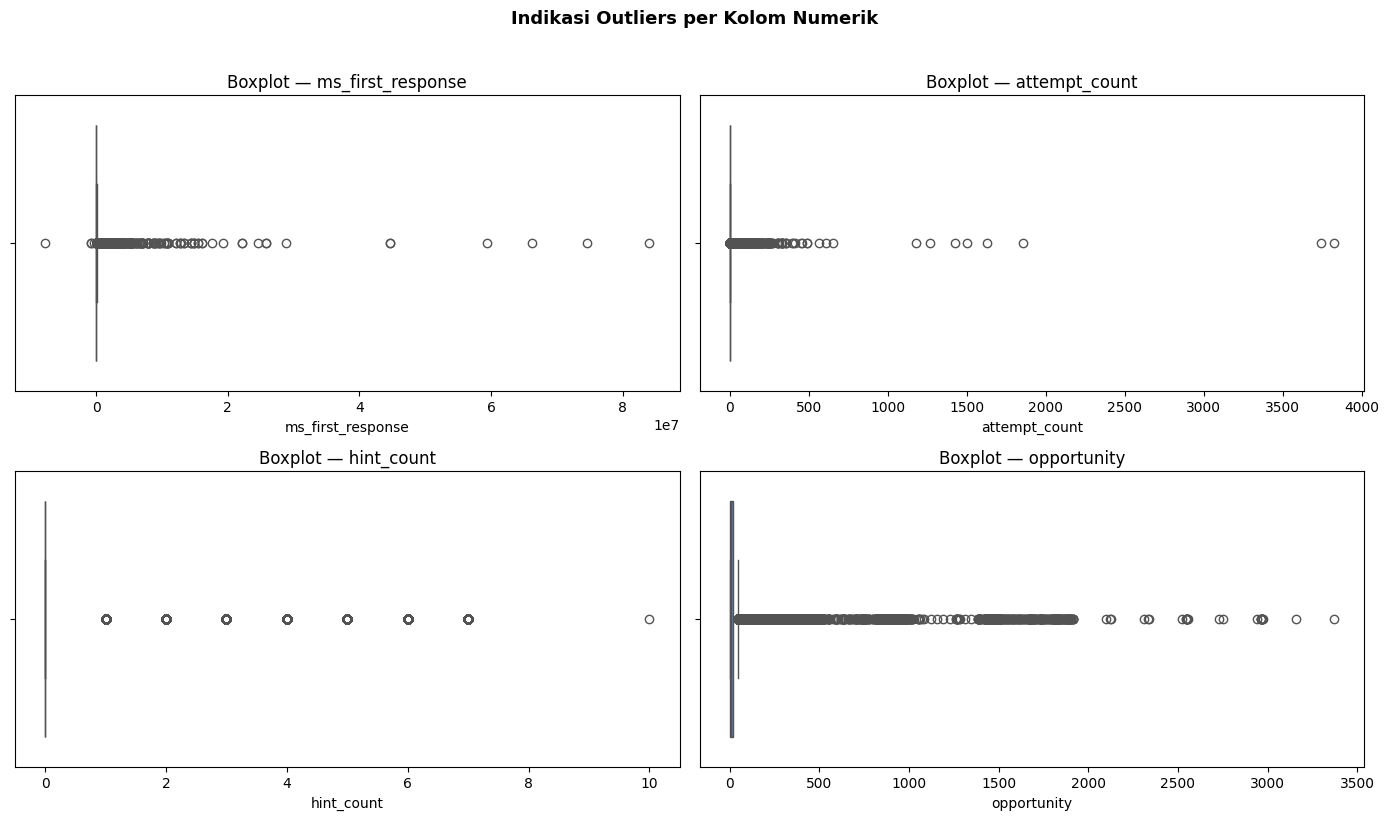

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

kolom_outlier = ['ms_first_response', 'attempt_count', 'hint_count', 'opportunity']

for col in kolom_outlier:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outlier_count = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_pct   = outlier_count / len(df) * 100
    print(f"\n[{col}]")
    print(f"  Q1 / Q3         : {Q1:.2f} / {Q3:.2f}")
    print(f"  IQR             : {IQR:.2f}")
    print(f"  Lower / Upper   : {lower:.2f} / {upper:.2f}")
    print(f"  Outlier count   : {outlier_count:,} ({outlier_pct:.2f}%)")

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(kolom_outlier):
    sns.boxplot(x=df[col], ax=axes[i], color='#378ADD')
    axes[i].set_title(f'Boxplot — {col}')
    axes[i].set_xlabel(col)

plt.suptitle('Indikasi Outliers per Kolom Numerik', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Insight Cek Indikasi Outliers**


*   ms_first_response: Terdapat 32.289 baris atau 9.31% yang terdeteksi sebagai outlier. Nilai negatif dan ekstrem lebih dari 1 jam tidak masuk akal secara logis karena waktu pengerjaan tidak mungkin bernilai negatif atau memakan waktu berjam-jam. Penanganannya adalah menghapus baris dengan nilai negatif, nol, dan lebih dari 3.600.000 ms saat proses cleaning.
*   attempt_count: Terdapat 77.831 baris atau 22.44% yang terflag sebagai outlier. Namun ini bukan data rusak, melainkan metode IQR terlalu sensitif karena 75% data terkonsentrasi di nilai 1. Nilai lebih dari 1 tetap valid karena siswa memang bisa mengulang soal.
*   hint_count: Terdapat 59.854 baris atau 17.26% yang terflag. Sama seperti attempt_count, IQR bernilai 0 sehingga semua nilai di atas 0 dianggap outlier. Padahal nilai ini valid dan sudah dijelaskan konteksnya di cek hint contamination.
*   opportunity: Terdapat 39.463 baris atau 11.38% yang terflag. Siswa dengan nilai opportunity tinggi mencerminkan mereka yang butuh banyak pengulangan untuk menguasai suatu konsep.

# Cleaning Data

**Menangani Missing Values**



skill_name merupakan kolom utama yang akan digunakan sebagai identitas konsep dalam sequence construction. Baris yang tidak memiliki nilai pada kolom ini tidak dapat direpresentasikan dalam urutan interaksi siswa sehingga harus dihapus. Penghapusan dilakukan berdasarkan kolom skill_name karena kolom inilah yang menjadi acuan utama, bukan skill_id, mengingat skill_id di dataset ini bertipe object.

**Memfilter Baris Scaffold**

Baris dengan nilai original sama dengan 0 dieksklusi karena merupakan soal
scaffold yang bukan soal utama. Hanya baris dengan original sama dengan 1
yang dipertahankan agar sequence hanya mencerminkan interaksi siswa dengan
soal original.

**Menghapus Kolom Tidak Relevan**

Kolom Unnamed: 0 akan di-drop karena bukan bagian dari dataset asli melainkan index lama yang ikut tersimpan saat proses export CSV. Kolom answer_id dan bottom_hint juga akan di-drop karena masing-masing missing lebih dari 80% sehingga tidak memiliki nilai informasi yang cukup untuk digunakan dalam analisis maupun modeling.

**Menangani Anomali Response Time**

Kolom ms_first_response memiliki tiga kategori anomali yang harus ditangani. Pertama, 7 baris dengan nilai negatif yang mustahil secara logis akan dihapus. Kedua, 310 baris dengan nilai nol yang mengindikasikan error pencatatan sistem juga akan dihapus. Ketiga, 151 baris dengan nilai lebih dari 3.600.000 ms atau 1 jam akan dihapus karena mencerminkan sesi yang ditinggalkan siswa, bukan waktu pengerjaan yang sesungguhnya.

**Memperbaiki Tipe Data**

Kolom skill_id saat ini bertipe object karena adanya missing values dan format gabungan multiple skill. Setelah proses cleaning, tipe data kolom ini perlu dievaluasi kembali apakah akan dikonversi atau tetap dipertahankan sebagai object.

**Mendokumentasikan Hint Contamination**

Sebanyak 59.841 baris atau 17.3% dari total data adalah kasus di mana siswa menggunakan hint dan sistem otomatis menandai correct sama dengan 0. Baris-baris ini tidak dihapus karena tetap merupakan informasi valid tentang perilaku siswa, namun kondisi ini harus didokumentasikan dengan jelas sebagai catatan penting untuk AI Engineer.

## Menghapus Kolom Tidak Relevan

Setelah proses filtering kolom yang relevan, ditemukan bahwa kolom 'Unnamed: 0' masih terdapat di dalam dataframe. Kolom ini bukan bagian dari dataset asli
melainkan index lama yang tersimpan saat proses export CSV sebelumnya, sehingga
tidak memiliki nilai informasi apapun dan perlu dihapus.

In [ ]:
print(f"\nShape awal : {df_filtered.shape}")

if 'Unnamed: 0' in df_filtered.columns:
    df_filtered = df_filtered.drop(columns=['Unnamed: 0'])
    print(f"Kolom 'Unnamed: 0' berhasil di-drop")
else:
    print(f"Kolom 'Unnamed: 0' tidak ditemukan, skip")

print(f"Shape setelah drop kolom : {df_filtered.shape}")


Shape awal : (346860, 10)
Kolom 'Unnamed: 0' tidak ditemukan, skip
Shape setelah drop kolom : (346860, 10)


## Memfilter Baris Scaffold

Dataset ASSISTments mengandung dua jenis soal yaitu soal original dan soal
scaffold. Soal scaffold merupakan sub-problem atau soal bantuan yang muncul
ketika siswa kesulitan mengerjakan soal utama, sehingga tidak merepresentasikan
interaksi pembelajaran yang independen. Untuk memastikan sequence yang dibangun
hanya mencerminkan interaksi siswa dengan soal-soal utama, baris dengan nilai
original sama dengan 0 perlu dieksklusi dari dataset.

In [ ]:
shape_sebelum = df_filtered.shape
print(f"\nShape sebelum filter scaffold : {shape_sebelum}")
print(f"Baris scaffold (original=0)   : {(df_filtered['original'] == 0).sum():,}")
print(f"Baris original (original=1)   : {(df_filtered['original'] == 1).sum():,}")

# Filter hanya soal original
df_filtered = df_filtered[df_filtered['original'] == 1].copy()

# Drop kolom original karena sudah tidak diperlukan
df_filtered = df_filtered.drop(columns=['original'])

print(f"\nShape setelah filter scaffold : {df_filtered.shape}")
print(f"Baris terhapus                : {shape_sebelum[0] - df_filtered.shape[0]:,}")


Shape sebelum filter scaffold : (346860, 10)
Baris scaffold (original=0)   : 71,402
Baris original (original=1)   : 275,458

Shape setelah filter scaffold : (275458, 9)
Baris terhapus                : 71,402


## Handle Missing Values

Kolom skill_name merupakan identitas utama konsep matematika yang akan digunakan dalam sequence construction. Tanpa nilai skill_name, interaksi siswa tidak dapat diidentifikasi konsepnya sehingga tidak bisa direpresentasikan dalam sequence. Oleh karena itu, seluruh baris yang tidak memiliki nilai pada kolom skill_name harus dihapus dari dataset.

In [ ]:
shape_sebelum = df_filtered.shape
print(f"\nShape sebelum handle missing : {shape_sebelum}")
print(f"\nMissing values sebelum cleaning:")
print(df_filtered.isnull().sum())

# Hapus baris tanpa skill_name
df_filtered = df_filtered.dropna(subset=['skill_name']).copy()

print(f"\nMissing values setelah cleaning:")
print(df_filtered.isnull().sum())
print(f"\nShape setelah handle missing  : {df_filtered.shape}")
print(f"Baris terhapus                : {shape_sebelum[0] - df_filtered.shape[0]:,}")


Shape sebelum handle missing : (275458, 9)

Missing values sebelum cleaning:
order_id                 0
user_id                  0
skill_id             16059
skill_name           24053
correct                  0
hint_count               0
attempt_count            0
ms_first_response        0
opportunity              0
dtype: int64

Missing values setelah cleaning:
order_id             0
user_id              0
skill_id             0
skill_name           0
correct              0
hint_count           0
attempt_count        0
ms_first_response    0
opportunity          0
dtype: int64

Shape setelah handle missing  : (251405, 9)
Baris terhapus                : 24,053


**Insight**

Sebelum penghapusan, ditemukan missing values pada dua kolom yaitu skill_name sebanyak 24.053 baris dan skill_id sebanyak 16.059 baris. Namun setelah baris tanpa skill_name dihapus, missing values pada skill_id ikut bersih menjadi 0. Ini mengkonfirmasi bahwa baris yang tidak punya skill_name juga tidak punya skill_id, sehingga cukup melakukan penghapusan berdasarkan skill_name saja. Dataset sekarang tersisa 251.405 baris dengan 9 kolom dan sudah bebas dari missing values di seluruh kolom kritis

## Konversi Tipe Data

Setelah proses filtering dan penghapusan missing values, perlu dilakukan
pengecekan dan konversi tipe data untuk memastikan setiap kolom memiliki tipe yang sesuai dengan perannya. Hal ini dilakukan untuk efisiensi memori dan memastikan proses seperti sorting, groupby, dan sequence construction berjalan dengan benar.

In [ ]:
print(f"\nTipe data sebelum konversi:")
print(df_filtered.dtypes)

# Konversi skill_id ke string untuk konsistensi
df_filtered['skill_id'] = df_filtered['skill_id'].astype(str)

# Konversi user_id dan order_id ke int
df_filtered['user_id'] = df_filtered['user_id'].astype(int)
df_filtered['order_id'] = df_filtered['order_id'].astype(int)

# Konversi correct ke int
df_filtered['correct'] = df_filtered['correct'].astype(int)

# Konversi opportunity ke int
df_filtered['opportunity'] = df_filtered['opportunity'].astype(int)

print(f"\nTipe data setelah konversi:")
print(df_filtered.dtypes)


Tipe data sebelum konversi:
order_id              int64
user_id               int64
skill_id             object
skill_name           object
correct               int64
hint_count            int64
attempt_count         int64
ms_first_response     int64
opportunity           int64
dtype: object

Tipe data setelah konversi:
order_id              int64
user_id               int64
skill_id             object
skill_name           object
correct               int64
hint_count            int64
attempt_count         int64
ms_first_response     int64
opportunity           int64
dtype: object


## Cleaning Format Desimal

In [ ]:
# Cek sebelum cleaning
desimal_before = df_filtered[
    df_filtered['skill_id'].str.contains(r'\.0', regex=True, na=False)
]['skill_id'].nunique()
print(f"\nJumlah skill_id desimal sebelum cleaning : {desimal_before}")

# Bersihkan format desimal
df_filtered['skill_id'] = df_filtered['skill_id'].apply(
    lambda x: x.replace('.0', '') if isinstance(x, str) and '.' in x else x
)

# Verifikasi setelah cleaning
desimal_after = df_filtered[
    df_filtered['skill_id'].str.contains(r'\.0', regex=True, na=False)
]['skill_id'].nunique()
print(f"Jumlah skill_id desimal setelah cleaning : {desimal_after}")

print(f"\nSample skill_id setelah cleaning:")
print(df_filtered['skill_id'].unique()[:20])


Jumlah skill_id desimal sebelum cleaning : 22
Jumlah skill_id desimal setelah cleaning : 0

Sample skill_id setelah cleaning:
['1_13' '1_15' '1' '2_37_70' '2_37_48_77' '2_48_79' '2_37_48' '2_70' '4'
 '5_375' '5_102' '8' '9_14' '9_12' '9_15' '9_13' '10_12' '10_13' '10_18'
 '10_64']


## Verifikasi Hasil Cleaning Data

Setelah seluruh proses cleaning selesai, perlu dilakukan verifikasi menyeluruh untuk memastikan data sudah bersih dan siap digunakan untuk tahap selanjutnya. Verifikasi mencakup pengecekan shape akhir, missing values, tipe data, dan ringkasan jumlah baris yang terhapus di setiap tahap cleaning.

In [ ]:
print(f"\n--- Ringkasan Proses Cleaning ---")
print(f"Shape awal dataset         : (346,860 × 10)")
print(f"Setelah filter scaffold    : (275,458 × 9)  → terhapus 71,402 baris")
print(f"Setelah handle missing     : (251,405 × 9)  → terhapus 24,053 baris")
print(f"Shape akhir dataset        : {df_filtered.shape}")

total_terhapus = 346860 - df_filtered.shape[0]
print(f"\nTotal baris terhapus       : {total_terhapus:,} ({total_terhapus/346860*100:.1f}%)")
print(f"Total baris dipertahankan  : {df_filtered.shape[0]:,} ({df_filtered.shape[0]/346860*100:.1f}%)")

print(f"\n--- Missing Values Akhir ---")
print(df_filtered.isnull().sum())

print(f"\n--- Tipe Data Akhir ---")
print(df_filtered.dtypes)

print(f"\n--- Sample Data Bersih ---")
print(df_filtered.head(5).to_string())


--- Ringkasan Proses Cleaning ---
Shape awal dataset         : (346,860 × 10)
Setelah filter scaffold    : (275,458 × 9)  → terhapus 71,402 baris
Setelah handle missing     : (251,405 × 9)  → terhapus 24,053 baris
Shape akhir dataset        : (251405, 9)

Total baris terhapus       : 95,455 (27.5%)
Total baris dipertahankan  : 251,405 (72.5%)

--- Missing Values Akhir ---
order_id             0
user_id              0
skill_id             0
skill_name           0
correct              0
hint_count           0
attempt_count        0
ms_first_response    0
opportunity          0
dtype: int64

--- Tipe Data Akhir ---
order_id              int64
user_id               int64
skill_id             object
skill_name           object
correct               int64
hint_count            int64
attempt_count         int64
ms_first_response     int64
opportunity           int64
dtype: object

--- Sample Data Bersih ---
   order_id  user_id skill_id       skill_name  correct  hint_count  attempt_count  m

**Insight**

Dari 346.860 baris awal, total 95.455 baris atau 27.5% berhasil dibersihkan melalui dua tahap. Tahap pertama filter scaffold menghapus 71.402 baris soal bantuan, dan tahap kedua handle missing values menghapus 24.053 baris tanpa identitas konsep. Dataset akhir yang dipertahankan sebesar 251.405 baris atau 72.5% dari data awal. Seluruh kolom sudah bebas dari missing values dan tipe data sudah sesuai dengan peran masing-masing kolom.


# Multi-Skill Tag Assesment & Handling

Tujuan:
1. untuk identifikan adakah multi-skill tags
   pada kolom skill_id.

2. Menganalisis jumlah dan distribusi multi-skill.

3. Menentukan strategi preprocessing yang sesuai
   untuk kebutuhan Knowledge Tracing.

Catatan:
- karna Knowledge Tracing baseline biasanya pakai asumsi:
      1 interaction = 1 concept
- makanya, multi-skill perlu dianalisis
  sebelum sequence construction dilakukan.

Output:
- Statistik multi-skill
- Distribusi jumlah skill per interaction
- Sample data multi-skill
- Dataset hasil handling


In [ ]:
df_multi = df_filtered.copy()

# 1. Identifikasi format multiskill
print("Sample unique skill_id:")
print(df_multi['skill_id'].dropna().unique()[:20])

# 2. Deteksi dan menghitung jumlah multiskill
SEPARATOR = "_"
multi_skill_mask = (df_multi['skill_id'].astype(str).str.contains(SEPARATOR))

multi_skill_count = multi_skill_mask.sum()
multi_skill_percentage = (multi_skill_count / len(df_multi)) * 100
print("\n===== MULTI-SKILL STATISTICS =====")
print(f"Total interactions       : {len(df_multi):,}")
print(f"Multi-skill interactions : {multi_skill_count:,}")
print(f"Percentage               : {multi_skill_percentage:.2f}%")

print("\n===== SAMPLE MULTI-SKILL =====")
print(df_multi.loc[multi_skill_mask,['user_id', 'skill_id', 'correct']].head(10))

# 4. Jumlah skill per interaction
df_multi['skill_count'] = (df_multi['skill_id'].astype(str).apply(lambda x: len(x.split(SEPARATOR)))
)
print("\n===== SKILL COUNT DISTRIBUTION =====")
print(df_multi['skill_count'].value_counts().sort_index())

print("\n===== UNIQUE SKILL_ID CARDINALITY =====")
unique_skill_count = (df_filtered['skill_id'].nunique())
print(f"Total unique skill_id : {unique_skill_count:,}")

Sample unique skill_id:
['1_13' '1_15' '1' '2_37_70' '2_37_48_77' '2_48_79' '2_37_48' '2_70' '4'
 '5_375' '5_102' '8' '9_14' '9_12' '9_15' '9_13' '10_12' '10_13' '10_18'
 '10_64']

===== MULTI-SKILL STATISTICS =====
Total interactions       : 251,405
Multi-skill interactions : 44,827
Percentage               : 17.83%

===== SAMPLE MULTI-SKILL =====
   user_id skill_id  correct
0    64525     1_13        1
1    64525     1_13        1
2    70363     1_13        0
3    70363     1_13        1
4    70363     1_15        0
5    70363     1_15        1
6    70363     1_15        1
7    70363     1_13        1
8    70677     1_15        1
9    70677     1_13        1

===== SKILL COUNT DISTRIBUTION =====
skill_count
1    206578
2     38794
3      4354
4      1679
Name: count, dtype: int64

===== UNIQUE SKILL_ID CARDINALITY =====
Total unique skill_id : 136


In [ ]:
# Option B - keep as composite skill
df_cleaned = df_multi.copy()
print("\nOPTION B APPLIED:")
print("Multi-skill retained as composite concept.")

print("\n===== FINAL DATASET =====")
print(f"Final total interactions : {len(df_cleaned):,}")
print("\nSample cleaned skill_id:")
print(df_cleaned['skill_id'].head(10))



OPTION B APPLIED:
Multi-skill retained as composite concept.

===== FINAL DATASET =====
Final total interactions : 251,405

Sample cleaned skill_id:
0    1_13
1    1_13
2    1_13
3    1_13
4    1_15
5    1_15
6    1_15
7    1_13
8    1_15
9    1_13
Name: skill_id, dtype: object


# Handling Strategy

---


1. Option a → drop multi-skill (tidak available, data terlalu besar)
2. Option b → keep as composite skill
3. Option c → take first skill (tidak available, karna bisa menyebabkan misleading)
4. Option d → separate jadi multirows (takutnya sequence ambiguity)

Beberapa interaction memiliki multi-skill tags pada
kolom skill_id.

Ditemukan sekitar 17.83% interaction memiliki multi-skill tags pada kolom `skill_id`.

Karena proporsinya cukup signifikan, interaction multi-skill tidak dihapus supaya tidak menyebabkan hilangnya data dan rusaknya integritas sequence pembelajaran siswa.

multi-skill diperlakukan sebagai composite concept, sehingga setiap kombinasi skill dianggap sebagai satu representasi konsep unik dalam proses Knowledge Tracing.

opsi ini dipakai supaya informasi konseptual
tidak hilang selama proses preprocessing.


# Sequence Construction

Sequence Construction adalah tahap mengubah data tabular menjadi urutan interaksi siswa yang mencerminkan proses pembelajaran secara temporal.
Setiap siswa direpresentasikan sebagai sequence pasangan (skill_id, correct)
yang diurutkan berdasarkan order_id. Tahap ini merupakan tahap paling krusial
karena format output yang dihasilkan akan langsung digunakan oleh AI Engineer
sebagai input model Deep Knowledge Tracing.


In [ ]:
# Sort berdasarkan user_id dan order_id
seq_df = df_filtered.sort_values(by=['user_id', 'order_id']) \
                    .groupby('user_id') \
                    .agg({
                        'skill_id'  : list,
                        'correct'   : list,
                        'skill_name': list,
                        'order_id'  : list
                    }).reset_index()

# Buat kolom sequence sebagai pasangan (skill_id, correct) per interaksi
seq_df['sequence'] = seq_df.apply(
    lambda row: list(zip(row['skill_id'], row['correct'])), axis=1
)

# Tambahkan panjang sequence per siswa
seq_df['seq_length'] = seq_df['skill_id'].apply(len)

print(f"\nSequence berhasil dibuat!")
print(f"Total siswa : {len(seq_df):,}")

print(f"\nStatistik Panjang Sequence")
print(f"Min panjang sequence    : {seq_df['seq_length'].min():,}")
print(f"Max panjang sequence    : {seq_df['seq_length'].max():,}")
print(f"Mean panjang sequence   : {seq_df['seq_length'].mean():.1f}")
print(f"Median panjang sequence : {seq_df['seq_length'].median():.1f}")

print(f"\nSample 5 Interaksi Pertama (3 siswa pertama)")
for i in range(3):
    print(f"\nSiswa user_id={seq_df['user_id'].iloc[i]}")
    print(f"  Panjang sequence    : {seq_df['seq_length'].iloc[i]}")
    print(f"  5 interaksi pertama : {seq_df['sequence'].iloc[i][:5]}")


Sequence berhasil dibuat!
Total siswa : 4,151

Statistik Panjang Sequence
Min panjang sequence    : 1
Max panjang sequence    : 925
Mean panjang sequence   : 60.6
Median panjang sequence : 19.0

Sample 5 Interaksi Pertama (3 siswa pertama)

Siswa user_id=14
  Panjang sequence    : 19
  5 interaksi pertama : [('2_37_70', 0), ('2_37_70', 1), ('2_37_70', 0), ('2_37_70', 0), ('2_37_70', 0)]

Siswa user_id=21825
  Panjang sequence    : 17
  5 interaksi pertama : [('10_12', 0), ('10_12', 1), ('10_12', 1), ('10_12', 1), ('10_13', 0)]

Siswa user_id=51950
  Panjang sequence    : 6
  5 interaksi pertama : [('311', 0), ('311', 1), ('311', 1), ('311', 1), ('312', 1)]


In [ ]:
# Cek format sequence siswa pertama
print("Tipe sequence    :", type(seq_df['sequence'].iloc[0]))
print("Panjang sequence :", len(seq_df['sequence'].iloc[0]))
print("Elemen pertama   :", seq_df['sequence'].iloc[0][0])
print("Elemen kedua     :", seq_df['sequence'].iloc[0][1])

Tipe sequence    : <class 'list'>
Panjang sequence : 19
Elemen pertama   : ('2_37_70', 0)
Elemen kedua     : ('2_37_70', 1)


**Insight**

Tipe sequence di atas adalah list dengan setiap elemennya berupa pasangan (skill_id, correct) per interaksi, contohnya ('2_37_70', 0) yang artinya siswa mengerjakan konsep 2_37_70 dan menjawab salah. Namun ditemukan nilai 312.0 dengan format desimal pada skill_id yang perlu dikonversi menjadi 312 agar konsisten dengan format skill_id lainnya.

## Cek Format Data

In [ ]:
# Cek berapa banyak skill_id dengan format desimal
desimal = seq_df['skill_id'].apply(
    lambda lst: sum(1 for s in lst if '.' in str(s))
).sum()
print(f"\nJumlah skill_id berformat desimal : {desimal:,}")

# Bersihkan format desimal dari skill_id
seq_df['skill_id'] = seq_df['skill_id'].apply(
    lambda lst: [s.replace('.0', '') if '.' in str(s) else s for s in lst]
)

# Update sequence setelah cleaning skill_id
seq_df['sequence'] = seq_df.apply(
    lambda row: list(zip(row['skill_id'], row['correct'])), axis=1
)

# Verifikasi
desimal_after = seq_df['skill_id'].apply(
    lambda lst: sum(1 for s in lst if '.' in str(s))
).sum()
print(f"Jumlah skill_id berformat desimal setelah cleaning : {desimal_after:,}")
print(f"\nCleaning skill_id selesai!")
print(f"\nSample skill_id siswa ketiga : {seq_df['skill_id'].iloc[2]}")


Jumlah skill_id berformat desimal : 0
Jumlah skill_id berformat desimal setelah cleaning : 0

Cleaning skill_id selesai!

Sample skill_id siswa ketiga : ['311', '311', '311', '311', '312', '312']


**Insight**

Ini berarti nilai 312.0 yang terlihat di sample sebelumnya kemungkinan hanya tampilan sementara saat sequence pertama kali dibuat, dan sudah otomatis terkonversi menjadi 312 saat proses groupby berlangsung. Terbukti dari sample skill_id siswa ketiga sekarang sudah menampilkan 312 tanpa desimal.

# Data Splitting

Data Splitting dilakukan untuk membagi dataset menjadi subset train dan test
berdasarkan student-level split. Hal ini dilakukan untuk memastikan bahwa seluruh sequence interaksi dari satu siswa hanya berada pada salah satu subset saja, sehingga tidak terjadi data leakage. Dengan cara ini, model akan diuji pada siswa yang benar-benar belum pernah dilihat sebelumnya, sehingga mencerminkan kondisi nyata ketika model digunakan untuk memprediksi performa siswa baru. Data splitting dilakukan menggunakan student-level split dengan rasio 70:15:15 untuk train, validation, dan test. Validation set ditambahkan untuk membantu AI Engineer memantau performa model selama proses training
dan mencegah overfitting.

In [ ]:
from sklearn.model_selection import train_test_split

# Ambil seluruh user_id unik
user_ids = seq_df['user_id'].unique()
print(f"\nTotal siswa : {len(user_ids):,}")

# Step 1 — Split train (70%) dan sisanya (30%)
train_ids, temp_ids = train_test_split(
    user_ids,
    test_size=0.30,
    random_state=42,
    shuffle=True
)

# Step 2 — Split sisanya menjadi val (15%) dan test (15%)
val_ids, test_ids = train_test_split(
    temp_ids,
    test_size=0.50,
    random_state=42,
    shuffle=True
)

print(f"\nSiswa train : {len(train_ids):,} ({len(train_ids)/len(user_ids)*100:.1f}%)")
print(f"Siswa val   : {len(val_ids):,} ({len(val_ids)/len(user_ids)*100:.1f}%)")
print(f"Siswa test  : {len(test_ids):,} ({len(test_ids)/len(user_ids)*100:.1f}%)")

# Filter seq_df berdasarkan split
train_df = seq_df[seq_df['user_id'].isin(train_ids)].reset_index(drop=True)
val_df   = seq_df[seq_df['user_id'].isin(val_ids)].reset_index(drop=True)
test_df  = seq_df[seq_df['user_id'].isin(test_ids)].reset_index(drop=True)

print(f"\nVerifikasi Split")
print(f"Shape train_df : {train_df.shape}")
print(f"Shape val_df   : {val_df.shape}")
print(f"Shape test_df  : {test_df.shape}")

# Pastikan tidak ada overlap
overlap_train_val  = set(train_df['user_id']).intersection(set(val_df['user_id']))
overlap_train_test = set(train_df['user_id']).intersection(set(test_df['user_id']))
overlap_val_test   = set(val_df['user_id']).intersection(set(test_df['user_id']))

print(f"\nOverlap train & val  : {len(overlap_train_val)}")
print(f"Overlap train & test : {len(overlap_train_test)}")
print(f"Overlap val & test   : {len(overlap_val_test)}")


Total siswa : 4,151

Siswa train : 2,905 (70.0%)
Siswa val   : 623 (15.0%)
Siswa test  : 623 (15.0%)

Verifikasi Split
Shape train_df : (2905, 7)
Shape val_df   : (623, 7)
Shape test_df  : (623, 7)

Overlap train & val  : 0
Overlap train & test : 0
Overlap val & test   : 0


**Insight**

Data splitting berhasil dilakukan dengan rasio 70:15:15 menggunakan student-level split. Dari total 4.151 siswa, sebanyak 2.905 siswa atau 70% masuk ke subset train, 623 siswa atau 15% masuk ke subset validation, dan 623 siswa atau 15% masuk ke subset test. Hasil verifikasi menunjukkan overlap antara ketiga subset adalah 0 yang artinya tidak ada satu pun siswa yang sequence-nya terbagi antara subset manapun.

## Simpan Data

Setelah seluruh proses cleaning, sequence construction, dan data splitting selesai, data disimpan ke dalam format CSV untuk digunakan oleh AI Engineer dalam proses modeling. Terdapat empat file output yang dihasilkan yaitu clean_data.csv sebagai data lengkap hasil cleaning, serta train_data.csv, val_data.csv, dan test_data.csv sebagai data hasil splitting.

In [ ]:
# Simpan data hasil cleaning
df_filtered.to_csv('clean_data.csv', index=False)
print(f"\nclean_data.csv tersimpan  — {df_filtered.shape[0]:,} baris")

# Simpan train data
train_df.to_csv('train_data.csv', index=False)
print(f"train_data.csv tersimpan  — {train_df.shape[0]:,} siswa")

# Simpan val data
val_df.to_csv('val_data.csv', index=False)
print(f"val_data.csv tersimpan    — {val_df.shape[0]:,} siswa")

# Simpan test data
test_df.to_csv('test_data.csv', index=False)
print(f"test_data.csv tersimpan   — {test_df.shape[0]:,} siswa")

print(f"\nRingkasan File Output")
print(f"clean_data.csv : data bersih sebelum splitting")
print(f"train_data.csv : {train_df.shape[0]:,} siswa untuk training model")
print(f"val_data.csv   : {val_df.shape[0]:,} siswa untuk validasi model")
print(f"test_data.csv  : {test_df.shape[0]:,} siswa untuk testing model")


clean_data.csv tersimpan  — 251,405 baris
train_data.csv tersimpan  — 2,905 siswa
val_data.csv tersimpan    — 623 siswa
test_data.csv tersimpan   — 623 siswa

Ringkasan File Output
clean_data.csv : data bersih sebelum splitting
train_data.csv : 2,905 siswa untuk training model
val_data.csv   : 623 siswa untuk validasi model
test_data.csv  : 623 siswa untuk testing model


# Mengantisipasi Misleading name_skill


# Global Mapping

Sebelum melakukan explode, perlu dibangun terlebih dahulu mapping antara skill_id dan skill_name dari dataset. Mapping ini dibuat dengan mengambil pasangan skill_id dan skill_name dari interaksi yang hanya memiliki single skill tag. Mapping ini akan digunakan sebagai referensi untuk memberikan nama skill yang tepat pada setiap tag hasil explode. Jika suatu tag tidak ditemukan dalam mapping, tag tersebut akan diberi label sementara "Unknown_{id}" yang akan ditangani pada tahap berikutnya.

In [ ]:
df_multi = df_filtered.copy()

# 1. Identifikasi format multiskill
print("\n===== MAIN DATA =====")
print("Sample unique skill_id:")
print(df_multi['skill_id'].dropna().unique()[:20])

# 2. Deteksi dan menghitung jumlah multiskill
SEPARATOR = "_"
multi_skill_mask = (df_multi['skill_id'].astype(str).str.contains(SEPARATOR))

multi_skill_count = multi_skill_mask.sum()
multi_skill_percentage = (multi_skill_count / len(df_multi)) * 100
print("\n===== MULTI-SKILL STATISTICS =====")
print(f"Total interactions       : {len(df_multi):,}")
print(f"Multi-skill interactions : {multi_skill_count:,}")
print(f"Percentage               : {multi_skill_percentage:.2f}%")

print("\n===== SAMPLE MULTI-SKILL =====")
print(df_multi.loc[multi_skill_mask,['user_id', 'skill_id', 'correct']].head(10))

# 4. Jumlah skill per interaction
df_multi['skill_count'] = (df_multi['skill_id'].astype(str).apply(lambda x: len(x.split(SEPARATOR)))
)
print("\n===== SKILL COUNT DISTRIBUTION =====")
print(df_multi['skill_count'].value_counts().sort_index())

print("\n===== UNIQUE SKILL_ID CARDINALITY =====")
unique_skill_count = (df_filtered['skill_id'].nunique())
print(f"Total unique skill_id : {unique_skill_count:,}")


===== MAIN DATA =====
Sample unique skill_id:
['1_13' '1_15' '1' '2_37_70' '2_37_48_77' '2_48_79' '2_37_48' '2_70' '4'
 '5_375' '5_102' '8' '9_14' '9_12' '9_15' '9_13' '10_12' '10_13' '10_18'
 '10_64']

===== MULTI-SKILL STATISTICS =====
Total interactions       : 251,405
Multi-skill interactions : 44,827
Percentage               : 17.83%

===== SAMPLE MULTI-SKILL =====
   user_id skill_id  correct
0    64525     1_13        1
1    64525     1_13        1
2    70363     1_13        0
3    70363     1_13        1
4    70363     1_15        0
5    70363     1_15        1
6    70363     1_15        1
7    70363     1_13        1
8    70677     1_15        1
9    70677     1_13        1

===== SKILL COUNT DISTRIBUTION =====
skill_count
1    206578
2     38794
3      4354
4      1679
Name: count, dtype: int64

===== UNIQUE SKILL_ID CARDINALITY =====
Total unique skill_id : 136


In [ ]:
# mengecek data reference
print("\n===== REFERENCE DATA =====")
print("\n===== SKILL_ID FORMAT SAMPLE =====")
print(df_reference['skill_id'].dropna().unique()[:20])

print("\n===== DATA TYPE =====")
print(df_reference[['skill_id', 'skill_name']].dtypes)

print("\n===== MISSING VALUES =====")
print(df_reference[['skill_id', 'skill_name']].isna().sum())

print("\n===== UNIQUE CARDINALITY =====")
print(f"Unique skill_id   : "f"{df_reference['skill_id'].nunique()}")
print(f"Unique skill_name : "f"{df_reference['skill_name'].nunique()}")

print("\n===== SAMPLE ID-NAME PAIRS =====")
display(df_reference[['skill_id', 'skill_name']].drop_duplicates().head(10))

print("\n===== REFERENCE MULTI-SKILL =====")
SEPARATOR = "_"
multi_skill_mask_ref = (df_reference['skill_id'].astype(str).str.contains(SEPARATOR))
multi_skill_count_ref = multi_skill_mask_ref.sum()
multi_skill_percentage_ref = (multi_skill_count_ref / len(df_reference)) * 100
print(f"Total rows              : {len(df_reference):,}")
print(f"Multi-skill rows        : {multi_skill_count_ref:,}")
print(f"Percentage              : {multi_skill_percentage_ref:.2f}%")


===== REFERENCE DATA =====

===== SKILL_ID FORMAT SAMPLE =====
[ 1.  2.  4.  5.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17. 18. 21. 22. 24.
 25. 26.]

===== DATA TYPE =====
skill_id      float64
skill_name     object
dtype: object

===== MISSING VALUES =====
skill_id      66326
skill_name    78690
dtype: int64

===== UNIQUE CARDINALITY =====
Unique skill_id   : 123
Unique skill_name : 110

===== SAMPLE ID-NAME PAIRS =====


,skill_id,skill_name
0,1.0,Box and Whisker
3957,2.0,Circle Graph
10165,4.0,Histogram as Table or Graph
11969,5.0,Number Line
13864,8.0,Scatter Plot
15723,9.0,Stem and Leaf Plot
19551,10.0,Table
26385,11.0,Venn Diagram
44660,12.0,Mean
47599,13.0,Median



===== REFERENCE MULTI-SKILL =====
Total rows              : 525,534
Multi-skill rows        : 0
Percentage              : 0.00%


In [ ]:
# Normalize reference skill_id
df_reference_clean = df_reference.copy()
df_reference_clean['skill_id'] = (df_reference_clean['skill_id'].dropna().astype(int).astype(str))

print("===== NORMALIZED SKILL_ID SAMPLE =====")
print(df_reference_clean['skill_id'].dropna().unique()[:20])

===== NORMALIZED SKILL_ID SAMPLE =====
['1' '2' '4' '5' '8' '9' '10' '11' '12' '13' '14' '15' '16' '17' '18' '21'
 '22' '24' '25' '26']


In [ ]:
# Build skill main maping
main_mapping = {}
for _, row in df_multi.iterrows():
    skill_ids = str(row['skill_id']).split(SEPARATOR)
    skill_name = row['skill_name']
    if len(skill_ids) == 1:
        sid = skill_ids[0]
        if pd.notna(skill_name):
            if sid not in main_mapping:
                main_mapping[sid] = skill_name

print("\n===== MAIN MAPPING SAMPLE =====")
sample_mapping = list(main_mapping.items())[:10]
for sid, sname in sample_mapping:
    print(f"{sid} -> {sname}")

print(f"\nTotal mapped skills: {len(main_mapping)}")


===== MAIN MAPPING SAMPLE =====
1 -> Box and Whisker
4 -> Histogram as Table or Graph
8 -> Scatter Plot
11 -> Venn Diagram
12 -> Mean
13 -> Median
15 -> Range
16 -> Counting Methods
17 -> Probability of Two Distinct Events
18 -> Probability of a Single Event

Total mapped skills: 93


In [ ]:
# Cek skill yang belum termap
all_skill_ids = set()
for skills in df_multi['skill_id'].astype(str):
    split_skills = skills.split('_')
    all_skill_ids.update(split_skills)
mapped_skill_ids = set(main_mapping.keys())
unknown_skills = all_skill_ids - mapped_skill_ids

print("===== UNKNOWN SKILLS =====")
print(f"Total unknown skills: {len(unknown_skills)}")
print(sorted(unknown_skills))

===== UNKNOWN SKILLS =====
Total unknown skills: 21
['10', '102', '104', '14', '173', '190', '193', '2', '221', '321', '35', '37', '375', '48', '5', '53', '63', '64', '69', '74', '9']


In [ ]:
# Build reference mapping
reference_mapping = {}
for _, row in df_reference_clean.iterrows():
    if pd.isna(row['skill_id']):
        continue
    if pd.isna(row['skill_name']):
        continue
    sid = row['skill_id']
    if '_' not in sid:
        reference_mapping[sid] = row['skill_name']

print("\n===== REFERENCE MAPPING SAMPLE =====")
sample_reference = list(reference_mapping.items())[:10]
for sid, sname in sample_reference:
    print(f"{sid} -> {sname}")

print(f"Total reference mapping: {len(reference_mapping)}")


===== REFERENCE MAPPING SAMPLE =====
1 -> Box and Whisker
2 -> Circle Graph
4 -> Histogram as Table or Graph
5 -> Number Line
8 -> Scatter Plot
9 -> Stem and Leaf Plot
10 -> Table
11 -> Venn Diagram
12 -> Mean
13 -> Median
Total reference mapping: 111


In [ ]:
# Fill unknown skills only
final_mapping = main_mapping.copy()
filled_skills = []
for sid in unknown_skills:
    if sid in reference_mapping:
        final_mapping[sid] = reference_mapping[sid]
        filled_skills.append({'skill_id': sid, 'filled_skill_name':reference_mapping[sid]})

filled_skill_df = pd.DataFrame(filled_skills)

print("===== FILLED UNKNOWN SKILLS =====")
display(filled_skill_df.sort_values('skill_id'))
print(f"\nTotal filled skills: "f"{len(filled_skill_df)}")

===== FILLED UNKNOWN SKILLS =====


,skill_id,filled_skill_name
5,10,Table
4,14,Mode
11,173,Choose an Equation from Given Information
14,190,Intercept
12,193,Linear Equations
6,2,Circle Graph
17,221,Slope
1,321,Computation with Real Numbers
7,35,Effect of Changing Dimensions of a Shape Prpor...
2,375,Solving Inequalities



Total filled skills: 18


# Explode Multi Skill Interactions

Proses explode dilakukan untuk memisahkan setiap tag dari composite skill menjadi baris individual. Hal ini bertujuan untuk memperbaiki akurasi EDA yang sebelumnya hanya menghitung skill_name dari tag pertama composite skill saja. Setiap baris composite skill dipecah menjadi beberapa baris sesuai jumlah tag yang dimiliki, dengan kolom skill_id_single berisi tag individual dan skill_name_single berisi nama skill yang sesuai. Proses ini menghasilkan penambahan baris dari 251.405 menjadi 303.944 baris

In [ ]:
# EXPLODE COMPOSITE SKILLS
expanded_rows = []
for _, row in df_multi.iterrows():
    skill_ids = str(row['skill_id']).split(SEPARATOR)
    for sid in skill_ids:
        new_row = row.copy()
        new_row['skill_id_single'] = sid
        new_row['skill_name_single'] = (final_mapping.get(sid,f"Unresolved Skill ({sid})"))
        expanded_rows.append(new_row)

df_exploded = pd.DataFrame(expanded_rows)
print("===== EXPLODED DATASET =====")
print(f"Original rows : {len(df_multi):,}")
print(f"Expanded rows : {len(df_exploded):,}")

print("\n===== SAMPLE EXPLODED ROWS =====")
display(df_exploded[['skill_id','skill_id_single','skill_name_single','correct']].head(20))

# CHECK UNRESOLVED SKILLS
unresolved_rows = df_exploded[df_exploded['skill_name_single'].str.contains('Unresolved Skill')]

print("\n===== UNRESOLVED SKILL SUMMARY =====")
print(unresolved_rows[['skill_id_single','skill_name_single']].drop_duplicates().sort_values('skill_id_single'))
print(f"\nTotal unresolved skills: "f"{unresolved_rows['skill_id_single'].nunique()}")

===== EXPLODED DATASET =====
Original rows : 251,405
Expanded rows : 303,944

===== SAMPLE EXPLODED ROWS =====


,skill_id,skill_id_single,skill_name_single,correct
0,1_13,1,Box and Whisker,1
0,1_13,13,Median,1
1,1_13,1,Box and Whisker,1
1,1_13,13,Median,1
2,1_13,1,Box and Whisker,0
2,1_13,13,Median,0
3,1_13,1,Box and Whisker,1
3,1_13,13,Median,1
4,1_15,1,Box and Whisker,0
4,1_15,15,Range,0



===== UNRESOLVED SKILL SUMMARY =====
      skill_id_single       skill_name_single
12210             102  Unresolved Skill (102)
19585             104  Unresolved Skill (104)
3957               37   Unresolved Skill (37)

Total unresolved skills: 3


In [ ]:
# Save ke CSV
output_path = '/content/drive/MyDrive/Data_Project_Dicoding/clean_data_exploded.csv'

df_exploded.to_csv(output_path,index=False)

print(f"File berhasil disimpan di:\n{output_path}")

File berhasil disimpan di:
/content/drive/MyDrive/Data_Project_Dicoding/clean_data_exploded.csv


# Exploratory Data Analysis (EDA)

**EDA Global**

Dilakukan pada data tabular df_filtered untuk menganalisis pola interaksi siswa secara keseluruhan. Analisis ini mencakup distribusi jawaban benar dan salah, frekuensi pengerjaan per konsep, serta correctness rate per skill. Insight yang dihasilkan akan menjadi landasan untuk memahami karakteristik dataset sebelum masuk ke analisis khusus Knowledge Tracing.


Distribusi Jawaban:
  Benar (1) : 166,344 (66.17%)
  Salah (0) : 85,061 (33.83%)


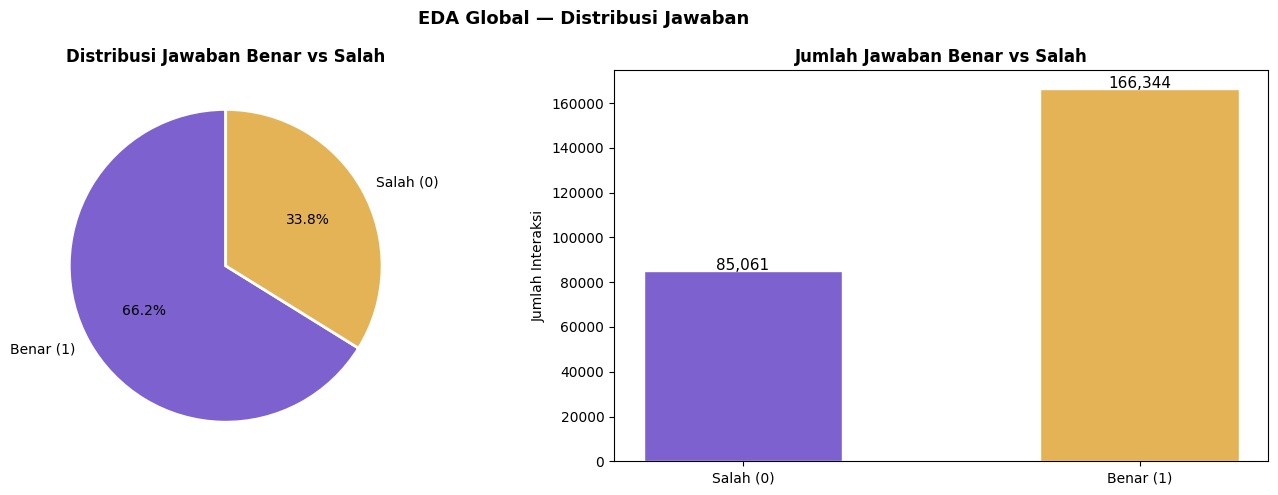

In [ ]:
# Distribusi Jawaban Benar vs Salah
correct_counts = df_filtered['correct'].value_counts()
correct_pct    = df_filtered['correct'].value_counts(normalize=True) * 100

print(f"\nDistribusi Jawaban:")
print(f"  Benar (1) : {correct_counts[1]:,} ({correct_pct[1]:.2f}%)")
print(f"  Salah (0) : {correct_counts[0]:,} ({correct_pct[0]:.2f}%)")

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 — Pie chart
axes[0].pie(
    correct_counts,
    labels=['Benar (1)', 'Salah (0)'],
    autopct='%1.1f%%',
    colors=['#7d61ce', '#E4b356'],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Distribusi Jawaban Benar vs Salah', fontweight='bold')

# Plot 2 — Bar chart
bars = axes[1].bar(
    ['Salah (0)', 'Benar (1)'],
    [correct_counts[0], correct_counts[1]],
    color=['#7d61ce', '#E4b356'],
    edgecolor='white',
    width=0.5
)
axes[1].set_title('Jumlah Jawaban Benar vs Salah', fontweight='bold')
axes[1].set_ylabel('Jumlah Interaksi')
for bar in bars:
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 500,
        f'{bar.get_height():,}',
        ha='center', fontsize=11
    )

plt.suptitle('EDA Global — Distribusi Jawaban', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Insight**

Distribusi jawaban pada dataset menunjukkan bahwa sebanyak 166.344 interaksi atau 66.17% dijawab dengan benar, sedangkan 85.061 interaksi atau 33.83% dijawab salah. Rasio ini menunjukkan dataset cukup balanced dan tidak terlalu didominasi oleh satu kelas. Perlu dicatat bahwa sebagian dari label salah (correct=0) merupakan kasus hint contamination yaitu jawaban yang ditandai salah bukan karena jawaban yang keliru secara murni, melainkan karena siswa menggunakan hint selama pengerjaan soal.

## Frekuensi Pengerjaan Per Skill

Analisis frekuensi pengerjaan per skill dilakukan untuk mengidentifikasi konsep matematika mana yang paling sering dan paling jarang dikerjakan oleh siswa. Informasi ini penting untuk memahami distribusi exposure siswa terhadap setiap konsep dalam dataset.


Total skill unik : 101

Top 10 Skill Terbanyak Dikerjakan:
                              skill_name  frequency
Conversion of Fraction Decimals Percents      18749
                            Circle Graph      18399
     Equation Solving Two or Fewer Steps      17311
                                   Table      13668
       Addition and Subtraction Integers      12741
               Subtraction Whole Numbers      11540
      Addition and Subtraction Fractions      11334
              Ordering Positive Decimals       9739
                        Counting Methods       8940
                              Proportion       8063

Bottom 10 Skill Paling Jarang Dikerjakan:
                                   skill_name  frequency
                             Percent Discount         47
                     Recognize Linear Pattern         36
              Interpreting Coordinate Graphs          33
                                     Midpoint         32
Quadratic Formula to Solve Quadratic Equ

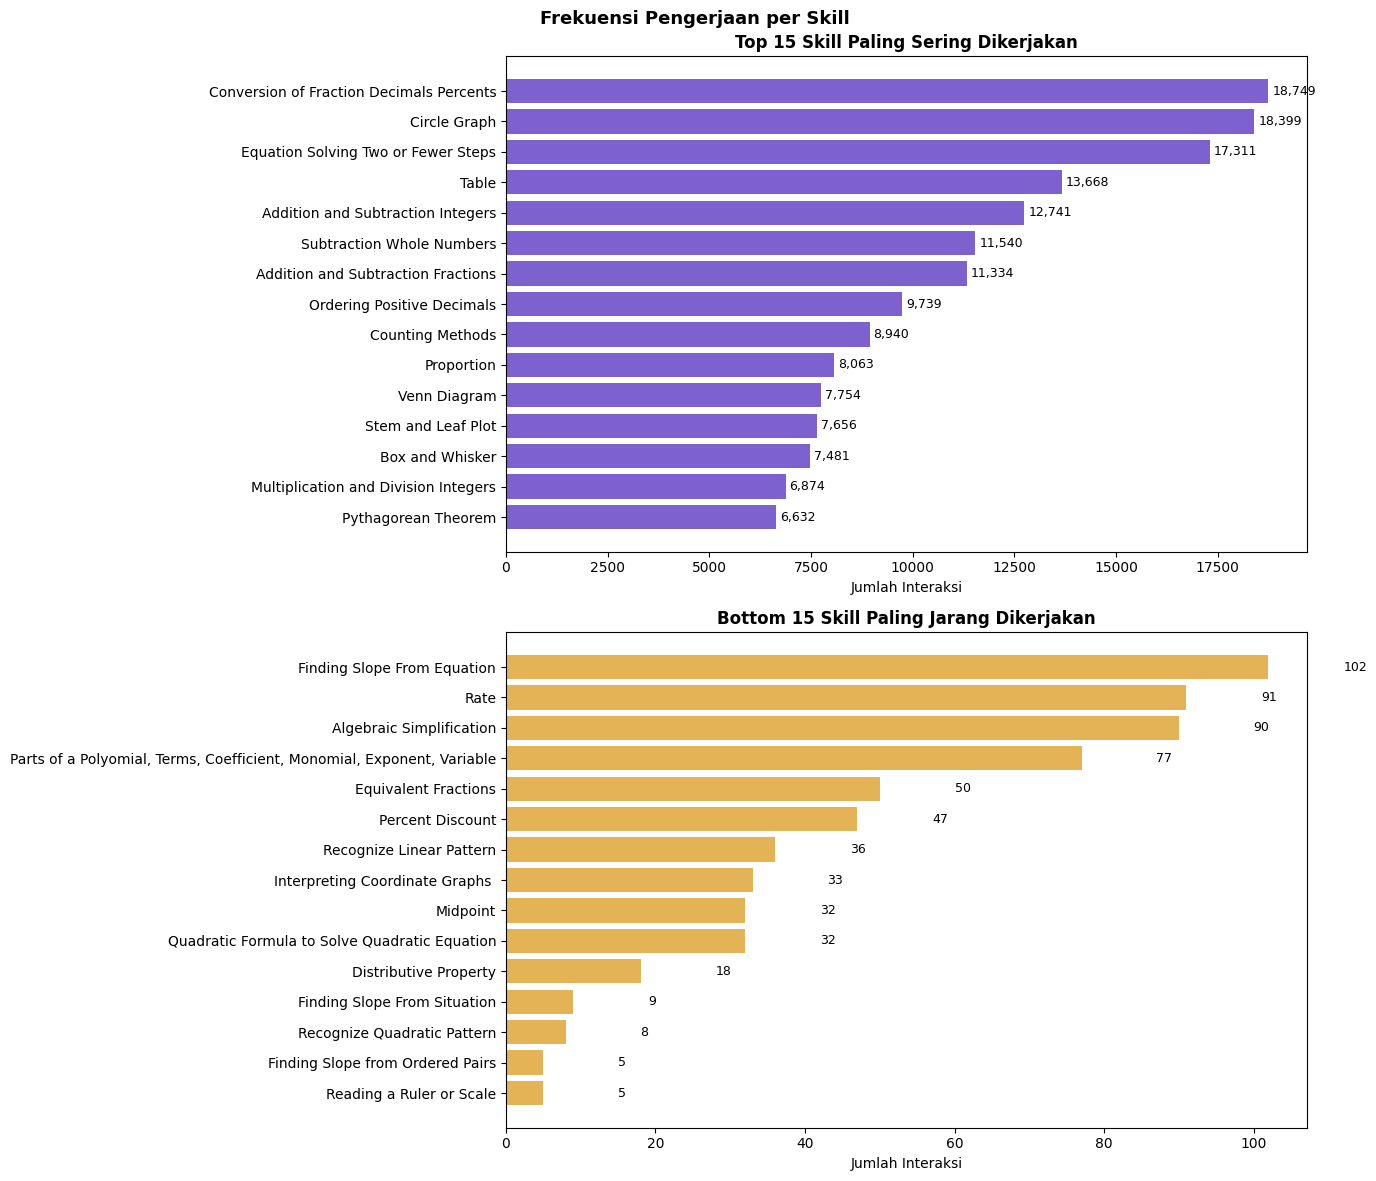

In [ ]:
# Hitung frekuensi per skill_name
skill_freq = df_exploded.groupby('skill_name').size() \
                        .sort_values(ascending=False) \
                        .reset_index(name='frequency')

print(f"\nTotal skill unik : {len(skill_freq)}")
print(f"\nTop 10 Skill Terbanyak Dikerjakan:")
print(skill_freq.head(10).to_string(index=False))
print(f"\nBottom 10 Skill Paling Jarang Dikerjakan:")
print(skill_freq.tail(10).to_string(index=False))

# Visualisasi top 15 skill
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Plot 1 — Top 15 skill
top15 = skill_freq.head(15)
axes[0].barh(
    top15['skill_name'][::-1],
    top15['frequency'][::-1],
    color='#7d61ce'
)
axes[0].set_title('Top 15 Skill Paling Sering Dikerjakan', fontweight='bold')
axes[0].set_xlabel('Jumlah Interaksi')
for i, v in enumerate(top15['frequency'][::-1]):
    axes[0].text(v + 100, i, f'{v:,}', va='center', fontsize=9)

# Plot 2 — Bottom 15 skill
bot15 = skill_freq.tail(15)
axes[1].barh(
    bot15['skill_name'][::-1],
    bot15['frequency'][::-1],
    color='#E4b356'
)
axes[1].set_title('Bottom 15 Skill Paling Jarang Dikerjakan', fontweight='bold')
axes[1].set_xlabel('Jumlah Interaksi')
for i, v in enumerate(bot15['frequency'][::-1]):
    axes[1].text(v + 10, i, f'{v:,}', va='center', fontsize=9)

plt.suptitle('Frekuensi Pengerjaan per Skill',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Correctness Rate per Skill

Analisis correctness rate per skill dilakukan untuk mengidentifikasi konsep matematika mana yang paling mudah dan paling sulit dikuasai oleh siswa. Informasi ini penting sebagai landasan untuk menentukan prioritas intervensi pembelajaran pada konsep dengan tingkat penguasaan terendah.


Top 10 Skill Termudah (Correctness Rate Tertinggi):
                                  skill_name  total  correct_rate
                          Nets of 3D Figures    280         95.00
                          Area Parallelogram    115         92.17
        Write Linear Equation from Situation    906         89.74
                       Distributive Property     18         88.89
                                  Congruence    603         88.72
                                Scatter Plot   1859         86.93
                              Area Rectangle    483         86.75
                               Area Triangle    286         85.66
D.4.8-understanding-concept-of-probabilities    456         84.65
                    Volume Rectangular Prism    926         84.02

Bottom 10 Skill Tersulit (Correctness Rate Terendah):
                                   skill_name  total  correct_rate
                                   Reflection    459         37.25
                            Alge

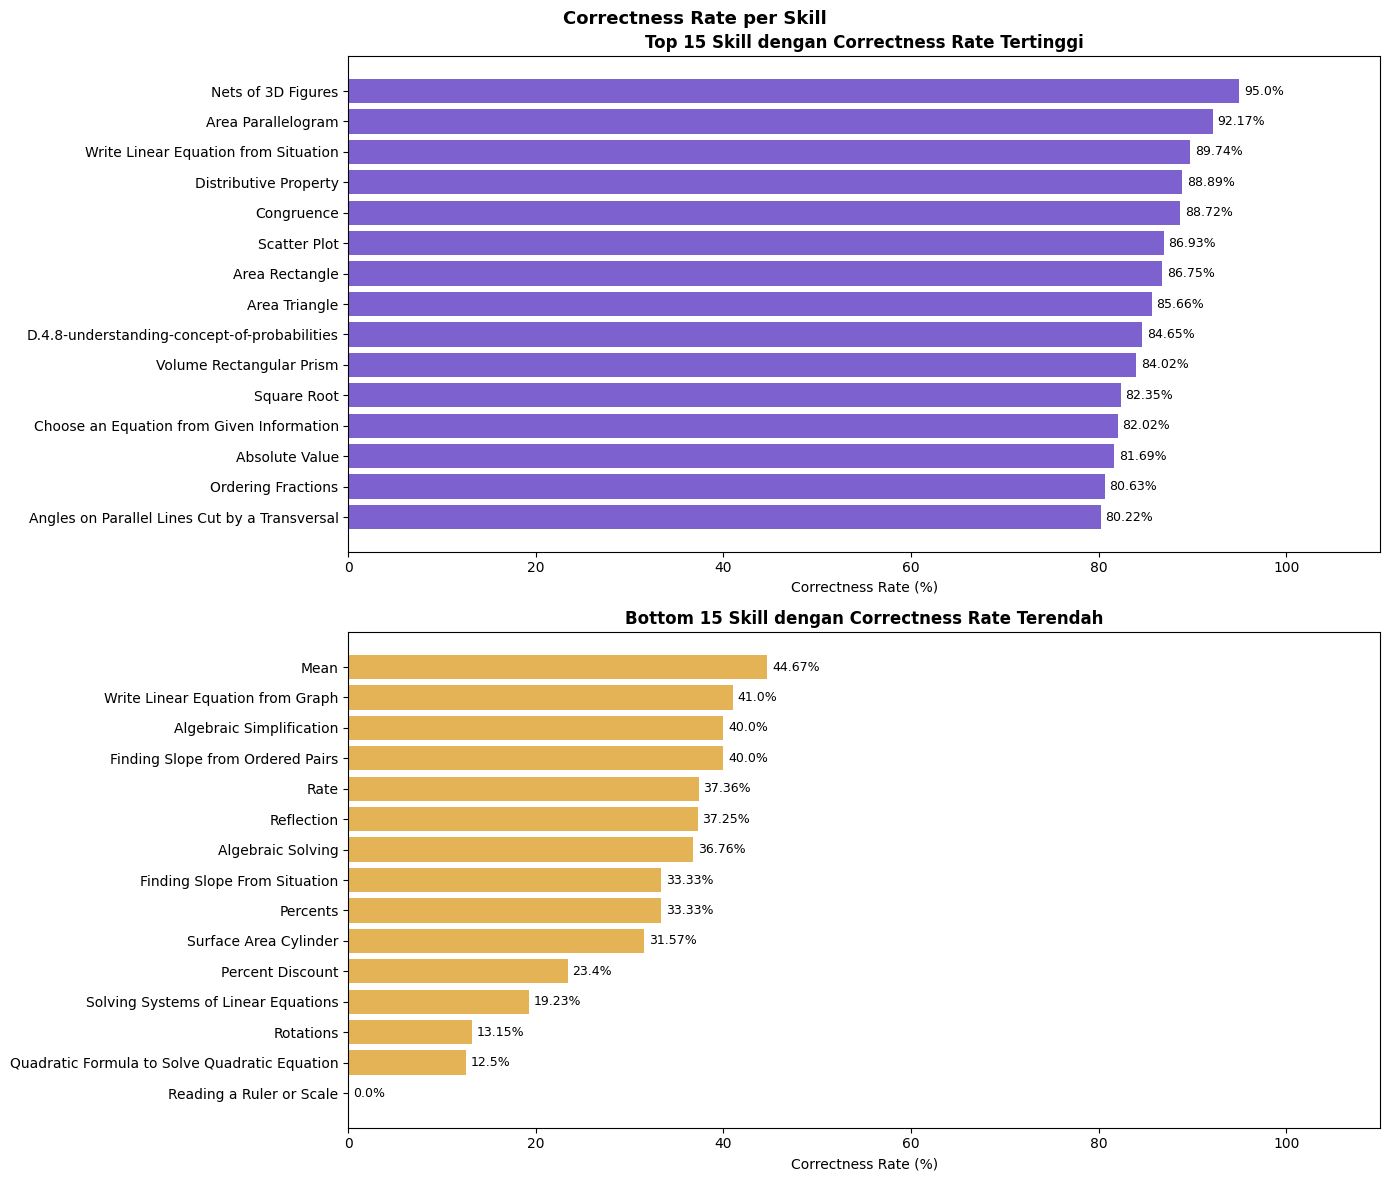

In [ ]:
# Hitung correctness rate per skill
skill_correct = df_exploded.groupby('skill_name').agg(
    total=('correct', 'count'),
    correct=('correct', 'sum')
).reset_index()

skill_correct['correct_rate'] = (
    skill_correct['correct'] / skill_correct['total'] * 100
).round(2)

skill_correct = skill_correct.sort_values('correct_rate', ascending=False)

print(f"\nTop 10 Skill Termudah (Correctness Rate Tertinggi):")
print(skill_correct.head(10)[['skill_name', 'total', 'correct_rate']].to_string(index=False))

print(f"\nBottom 10 Skill Tersulit (Correctness Rate Terendah):")
print(skill_correct.tail(10)[['skill_name', 'total', 'correct_rate']].to_string(index=False))

# Visualisasi
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Plot 1 - Top 15 skill termudah
top15 = skill_correct.head(15)
axes[0].barh(top15['skill_name'][::-1], top15['correct_rate'][::-1], color='#7d61ce')
axes[0].set_title('Top 15 Skill dengan Correctness Rate Tertinggi', fontweight='bold')
axes[0].set_xlabel('Correctness Rate (%)')
axes[0].set_xlim(0, 110)
for i, v in enumerate(top15['correct_rate'][::-1]):
    axes[0].text(v + 0.5, i, f'{v}%', va='center', fontsize=9)

# Plot 2 - Bottom 15 skill tersulit
bot15 = skill_correct.tail(15)
axes[1].barh(bot15['skill_name'][::-1], bot15['correct_rate'][::-1], color='#E4b356')
axes[1].set_title('Bottom 15 Skill dengan Correctness Rate Terendah', fontweight='bold')
axes[1].set_xlabel('Correctness Rate (%)')
axes[1].set_xlim(0, 110)
for i, v in enumerate(bot15['correct_rate'][::-1]):
    axes[1].text(v + 0.5, i, f'{v}%', va='center', fontsize=9)

plt.suptitle('Correctness Rate per Skill', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Correctness Rate per skill_id

Analisis correctness rate per skill_id dilakukan untuk melengkapi analisis sebelumnya yang menggunakan skill_name. Mengingat skill_id pada dataset ini dapat berupa composite skill dengan multiple tag, analisis ini bertujuan untuk melihat distribusi penguasaan konsep berdasarkan identifier unik skill_id termasuk kombinasi multi-skill yang diperlakukan sebagai satu konsep tersendiri sesuai keputusan sebelumnya.


Total unique skill_id : 136
Single skill          : 93
Composite skill       : 43

Top 10 Skill_ID Termudah (Correctness Rate Tertinggi):
skill_id      skill_type  total  correct_rate
      32    Single Skill    280         95.00
     295    Single Skill    115         92.17
   10_14 Composite Skill    970         91.44
      24    Single Skill    571         90.19
     323    Single Skill    906         89.74
     340    Single Skill     18         88.89
      51    Single Skill   2007         87.39
       8    Single Skill   1859         86.93
     296    Single Skill    483         86.75
     298    Single Skill    286         85.66

Bottom 10 Skill_ID Tersulit (Correctness Rate Terendah):
skill_id      skill_type  total  correct_rate
     299    Single Skill    491         31.57
     203    Single Skill     47         23.40
     350    Single Skill    234         19.23
  27_321 Composite Skill     21         19.05
   46_79 Composite Skill     25         16.00
     292    Single Sk

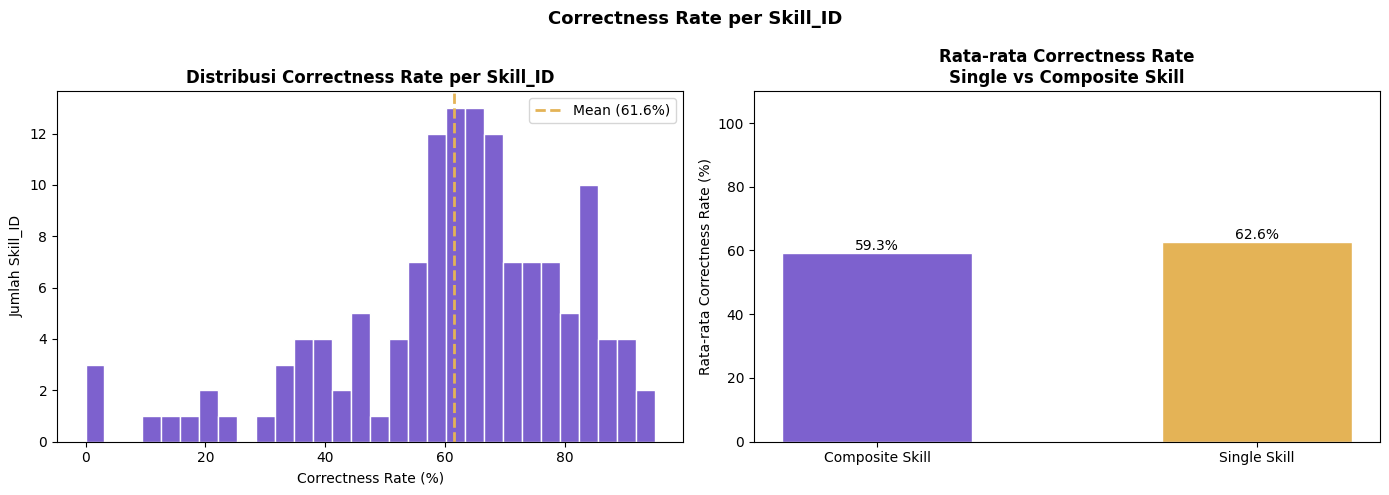

In [ ]:
# Hitung correctness rate per skill_id
skillid_correct = df_filtered.groupby('skill_id').agg(
    total=('correct', 'count'),
    correct=('correct', 'sum')
).reset_index()

skillid_correct['correct_rate'] = (
    skillid_correct['correct'] / skillid_correct['total'] * 100
).round(2)

skillid_correct = skillid_correct.sort_values(
    'correct_rate', ascending=False
)

# Pisahkan single skill dan composite skill
skillid_correct['skill_type'] = skillid_correct['skill_id'].apply(
    lambda x: 'Composite Skill' if '_' in str(x) else 'Single Skill'
)

print(f"\nTotal unique skill_id : {len(skillid_correct)}")
print(f"Single skill          : {(skillid_correct['skill_type'] == 'Single Skill').sum()}")
print(f"Composite skill       : {(skillid_correct['skill_type'] == 'Composite Skill').sum()}")

print(f"\nTop 10 Skill_ID Termudah (Correctness Rate Tertinggi):")
print(skillid_correct.head(10)[
    ['skill_id', 'skill_type', 'total', 'correct_rate']
].to_string(index=False))

print(f"\nBottom 10 Skill_ID Tersulit (Correctness Rate Terendah):")
print(skillid_correct.tail(10)[
    ['skill_id', 'skill_type', 'total', 'correct_rate']
].to_string(index=False))

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 — Distribusi correctness rate per skill_id
axes[0].hist(
    skillid_correct['correct_rate'],
    bins=30,
    color='#7d61ce',
    edgecolor='white'
)
axes[0].axvline(
    skillid_correct['correct_rate'].mean(),
    color='#E4b356',
    linestyle='--',
    linewidth=2,
    label=f'Mean ({skillid_correct["correct_rate"].mean():.1f}%)'
)
axes[0].set_title('Distribusi Correctness Rate per Skill_ID',
                   fontweight='bold')
axes[0].set_xlabel('Correctness Rate (%)')
axes[0].set_ylabel('Jumlah Skill_ID')
axes[0].legend()

# Plot 2 — Correctness rate single vs composite skill
type_correct = skillid_correct.groupby('skill_type').agg(
    avg_correct_rate=('correct_rate', 'mean')
).reset_index()

bars = axes[1].bar(
    type_correct['skill_type'],
    type_correct['avg_correct_rate'],
    color=['#7d61ce', '#E4b356'],
    edgecolor='white',
    width=0.5
)
axes[1].set_title('Rata-rata Correctness Rate\nSingle vs Composite Skill',
                   fontweight='bold')
axes[1].set_ylabel('Rata-rata Correctness Rate (%)')
axes[1].set_ylim(0, 110)
for bar in bars:
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1,
        f'{bar.get_height():.1f}%',
        ha='center', fontsize=10
    )

plt.suptitle('Correctness Rate per Skill_ID',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Insight**

Analisis correctness rate per skill_id mengungkapkan distribusi penguasaan konsep yang bervariasi di antara 136 unique skill_id yang terdiri dari 93 single skill dan 43 composite skill. Keberadaan composite skill yang cukup banyak mengkonfirmasi keputusan Option B untuk memperlakukan setiap kombinasi skill sebagai satu konsep unik tersendiri.

Dari sisi skill termudah, skill_id 32 mendominasi dengan correctness rate 95% yang merupakan single skill, diikuti skill_id 295 sebesar 92.17% dan menariknya skill_id 10_14 yang merupakan composite skill justru masuk top 3 dengan correctness rate 91.44% dari 970 interaksi yang menunjukkan bahwa tidak semua composite skill identik dengan kesulitan tinggi.

Di sisi skill tersulit, terdapat beberapa temuan. Skill_id 292_293 dan 5_102 yang merupakan composite skill memiliki correctness rate 0%, namun jumlah interaksinya sangat sedikit yaitu 14 dan 1 sehingga tidak representatif secara statistik. Yang lebih relevan adalah skill_id 292 dengan correctness rate 14.04% dari 413 interaksi dan skill_id 350.0 sebesar 19.23% dari 234 interaksi, keduanya memiliki jumlah data yang cukup besar sehingga tingkat kesulitannya dapat dianggap signifikan.


## Analisis Hint Usage

Analisis hint usage dilakukan untuk memahami seberapa besar pengaruh penggunaan hint terhadap pola jawaban siswa. Hal ini penting karena penggunaan hint secara otomatis menandai jawaban sebagai salah dalam sistem ASSISTments, sehingga perlu dipahami distribusinya agar tidak terjadi bias dalam interpretasi label correct oleh model.


Distribusi Hint Usage:
  Tanpa Hint : 216,358 (86.06%)
  Hint Banyak (>2) : 23,149 (9.21%)
  Hint Sedikit (1-2) : 11,898 (4.73%)

Correctness Rate per Hint Category:
     hint_category  total  correct_rate
  Hint Banyak (>2)  23149          0.00
Hint Sedikit (1-2)  11898          0.01
        Tanpa Hint 216358         76.88


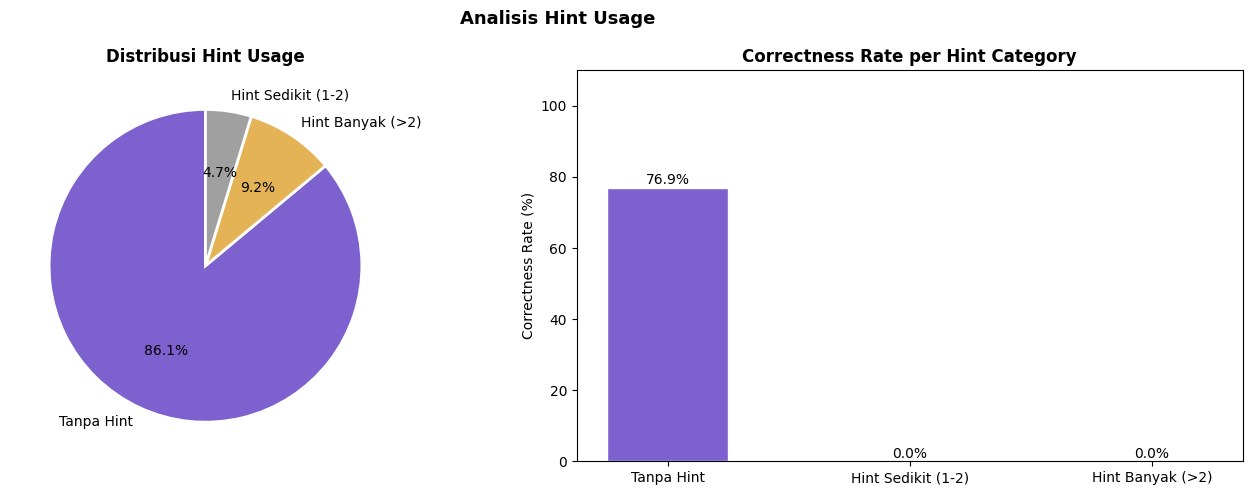

In [ ]:
# Kategorisasi hint usage
df_filtered['hint_category'] = df_filtered['hint_count'].apply(
    lambda x: 'Tanpa Hint' if x == 0 else
              'Hint Sedikit (1-2)' if x <= 2 else
              'Hint Banyak (>2)'
)

hint_cat = df_filtered['hint_category'].value_counts()
hint_pct = df_filtered['hint_category'].value_counts(normalize=True) * 100

print(f"\nDistribusi Hint Usage:")
for cat in hint_cat.index:
    print(f"  {cat} : {hint_cat[cat]:,} ({hint_pct[cat]:.2f}%)")

# Correctness rate per hint category
hint_correct = df_filtered.groupby('hint_category').agg(
    total=('correct', 'count'),
    correct=('correct', 'sum')
).reset_index()
hint_correct['correct_rate'] = (
    hint_correct['correct'] / hint_correct['total'] * 100
).round(2)

print(f"\nCorrectness Rate per Hint Category:")
print(hint_correct[['hint_category', 'total', 'correct_rate']].to_string(index=False))

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 — Distribusi hint category
axes[0].pie(
    hint_cat,
    labels=hint_cat.index,
    autopct='%1.1f%%',
    colors=['#7d61ce', '#E4b356', '#a0a0a0'],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Distribusi Hint Usage', fontweight='bold')

# Plot 2 — Correctness rate per hint category
order = ['Tanpa Hint', 'Hint Sedikit (1-2)', 'Hint Banyak (>2)']
hint_correct_sorted = hint_correct.set_index('hint_category').loc[order].reset_index()
bars = axes[1].bar(
    hint_correct_sorted['hint_category'],
    hint_correct_sorted['correct_rate'],
    color=['#7d61ce', '#E4b356', '#a0a0a0'],
    edgecolor='white',
    width=0.5
)
axes[1].set_title('Correctness Rate per Hint Category', fontweight='bold')
axes[1].set_ylabel('Correctness Rate (%)')
axes[1].set_ylim(0, 110)
for bar in bars:
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1,
        f'{bar.get_height():.1f}%',
        ha='center', fontsize=10
    )

plt.suptitle('Analisis Hint Usage', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Insight**

Sebagian besar interaksi yaitu 216.358 atau 86.06% dilakukan tanpa menggunakan hint sama sekali, sementara 11.898 interaksi atau 4.73% menggunakan hint sedikit antara 1 hingga 2 kali, dan 23.149 interaksi atau 9.21% menggunakan hint banyak lebih dari 2 kali.

Adapun temuan pada correctness rate per kategori hint yang sangat ekstrem. Siswa yang tidak menggunakan hint memiliki correctness rate 76.88%, sedangkan siswa yang menggunakan hint sedikit hanya 0.01% dan yang menggunakan hint banyak 0.00%. Pola ini mengkonfirmasi mekanisme ASSISTments yang secara otomatis menandai seluruh jawaban sebagai correct=0 ketika siswa menggunakan hint, tanpa memandang apakah siswa akhirnya memahami konsep atau tidak.

## Analisis Attempt Count

Analisis attempt count dilakukan untuk memahami pola pengulangan siswa dalam menjawab soal. Jumlah percobaan yang tinggi pada satu soal dapat mengindikasikan tingkat kesulitan materi atau persistensi siswa dalam memahami konsep. Informasi ini berguna untuk melengkapi pemahaman tentang behavior siswa selama proses pembelajaran.


Statistik Attempt Count:
count    251405.00
mean          1.57
std          13.40
min           0.00
25%           1.00
50%           1.00
75%           1.00
max        3824.00
Name: attempt_count, dtype: float64

Distribusi Attempt Count:
  1 Percobaan : 199,370 (79.30%)
  2-3 Percobaan : 40,323 (16.04%)
  >3 Percobaan : 11,712 (4.66%)

Correctness Rate per Attempt Category:
attempt_category  total  correct_rate
     1 Percobaan 199370         82.98
   2-3 Percobaan  40323          2.18
    >3 Percobaan  11712          0.23


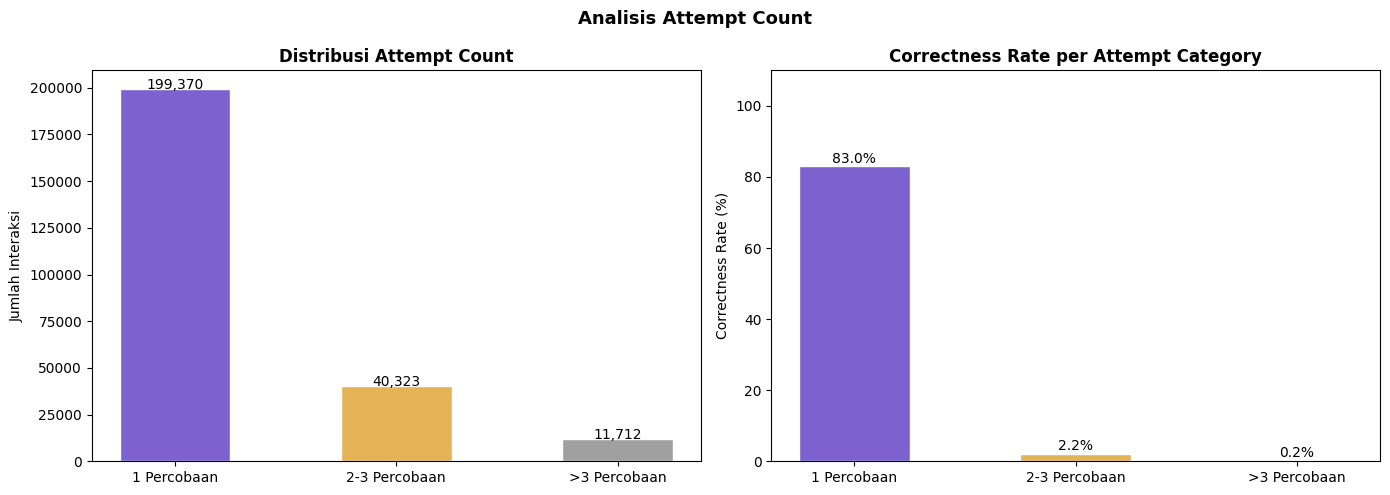

In [ ]:
# Statistik attempt count
print(f"\nStatistik Attempt Count:")
print(df_filtered['attempt_count'].describe().round(2))

# Kategorisasi attempt count
df_filtered['attempt_category'] = df_filtered['attempt_count'].apply(
    lambda x: '1 Percobaan' if x == 1 else
              '2-3 Percobaan' if x <= 3 else
              '>3 Percobaan'
)

attempt_cat = df_filtered['attempt_category'].value_counts()
attempt_pct = df_filtered['attempt_category'].value_counts(normalize=True) * 100

print(f"\nDistribusi Attempt Count:")
for cat in attempt_cat.index:
    print(f"  {cat} : {attempt_cat[cat]:,} ({attempt_pct[cat]:.2f}%)")

# Correctness rate per attempt category
attempt_correct = df_filtered.groupby('attempt_category').agg(
    total=('correct', 'count'),
    correct=('correct', 'sum')
).reset_index()
attempt_correct['correct_rate'] = (
    attempt_correct['correct'] / attempt_correct['total'] * 100
).round(2)

print(f"\nCorrectness Rate per Attempt Category:")
print(attempt_correct[['attempt_category', 'total', 'correct_rate']].to_string(index=False))

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 — Distribusi attempt category
order = ['1 Percobaan', '2-3 Percobaan', '>3 Percobaan']
attempt_cat_sorted = attempt_cat.reindex(order)
axes[0].bar(
    attempt_cat_sorted.index,
    attempt_cat_sorted.values,
    color=['#7d61ce', '#E4b356', '#a0a0a0'],
    edgecolor='white',
    width=0.5
)
axes[0].set_title('Distribusi Attempt Count', fontweight='bold')
axes[0].set_ylabel('Jumlah Interaksi')
for i, v in enumerate(attempt_cat_sorted.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontsize=10)

# Plot 2 — Correctness rate per attempt category
attempt_correct_sorted = attempt_correct.set_index(
    'attempt_category').loc[order].reset_index()
bars = axes[1].bar(
    attempt_correct_sorted['attempt_category'],
    attempt_correct_sorted['correct_rate'],
    color=['#7d61ce', '#E4b356', '#a0a0a0'],
    edgecolor='white',
    width=0.5
)
axes[1].set_title('Correctness Rate per Attempt Category', fontweight='bold')
axes[1].set_ylabel('Correctness Rate (%)')
axes[1].set_ylim(0, 110)
for bar in bars:
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1,
        f'{bar.get_height():.1f}%',
        ha='center', fontsize=10
    )

plt.suptitle('Analisis Attempt Count',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Insight**

Analisis attempt count menunjukkan bahwa mayoritas siswa yaitu 199.370 interaksi atau 79.30% hanya membutuhkan satu kali percobaan untuk menjawab soal. Sebanyak 40.323 interaksi atau 16.04% membutuhkan 2 hingga 3 percobaan, dan 11.712 interaksi atau 4.66% membutuhkan lebih dari 3 percobaan.

Adapun temuan pola correctness rate per kategori attempt yang sangat mencolok. Siswa yang menjawab dalam satu percobaan memiliki correctness rate 82.98%, sedangkan yang membutuhkan 2 hingga 3 percobaan hanya 2.18% dan lebih dari 3 percobaan hanya 0.23%. Pola ini sangat logis karena dalam sistem ASSISTments, siswa yang mengulang percobaan pada soal yang sama umumnya sudah menggunakan hint terlebih dahulu yang secara otomatis menandai jawaban sebagai salah, sehingga correctness rate pada kategori attempt tinggi hampir mendekati nol.

Catatan untuk AI Engineer: Perlu diperhatikan bahwa nilai minimum attempt_count adalah 0 yang secara logis tidak masuk akal karena soal tercatat dikerjakan namun tidak ada percobaan sama sekali. Ini merupakan inkonsistensi data kecil. Selain itu nilai maksimum 3.824 yang jauh dari rata-rata 1.57 mengkonfirmasi adanya outlier ekstrem yang kemungkinan merupakan error sistem atau perilaku tidak wajar dari siswa tertentu.

## Analisis Opportunity

Analisis opportunity dilakukan untuk memahami pola pengulangan siswa dalam mengerjakan soal dengan konsep yang sama. Kolom opportunity mencatat urutan keberapa siswa bertemu dengan suatu konsep, sehingga dapat digunakan untuk menganalisis learning progression siswa secara temporal. Semakin tinggi nilai opportunity, semakin sering siswa berinteraksi dengan konsep tersebut.


Statistik Opportunity:
count    251405.00
mean         15.21
std          70.62
min           1.00
25%           3.00
50%           6.00
75%          13.00
max        3371.00
Name: opportunity, dtype: float64

Distribusi Opportunity:
  Awal (1-5) : 113,750 (45.25%)
  Menengah (6-20) : 100,949 (40.15%)
  Lanjut (>20) : 36,706 (14.60%)

Correctness Rate per Opportunity Category:
opportunity_category  total  correct_rate
          Awal (1-5) 113750         66.03
        Lanjut (>20)  36706         62.15
     Menengah (6-20) 100949         67.78


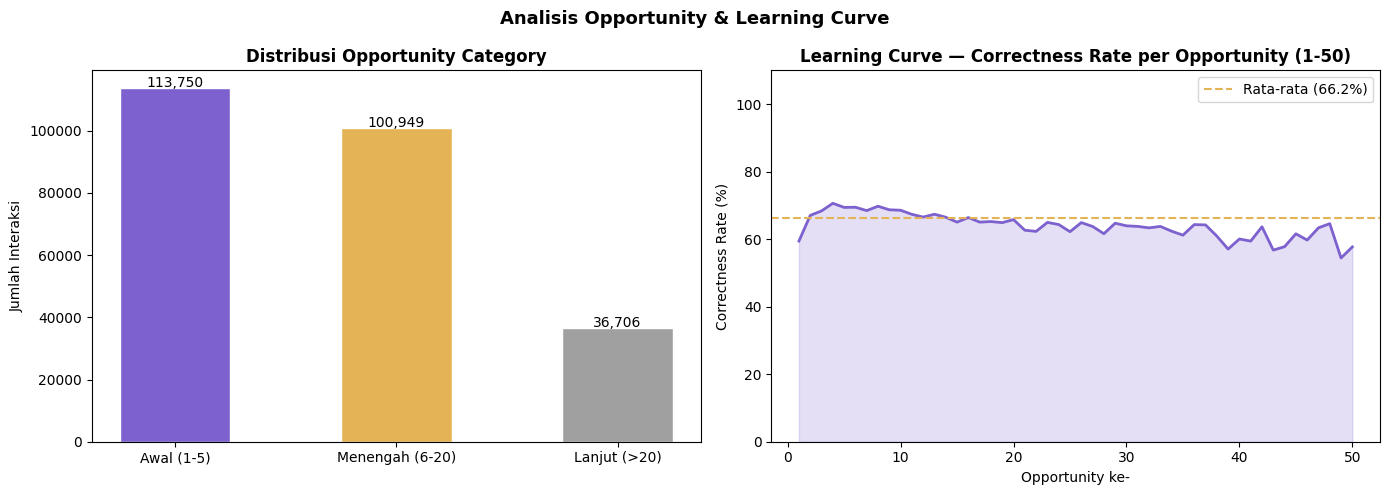

In [ ]:
# Statistik opportunity
print(f"\nStatistik Opportunity:")
print(df_filtered['opportunity'].describe().round(2))

# Kategorisasi opportunity
df_filtered['opportunity_category'] = df_filtered['opportunity'].apply(
    lambda x: 'Awal (1-5)' if x <= 5 else
              'Menengah (6-20)' if x <= 20 else
              'Lanjut (>20)'
)

opp_cat = df_filtered['opportunity_category'].value_counts()
opp_pct = df_filtered['opportunity_category'].value_counts(normalize=True) * 100

print(f"\nDistribusi Opportunity:")
for cat in opp_cat.index:
    print(f"  {cat} : {opp_cat[cat]:,} ({opp_pct[cat]:.2f}%)")

# Correctness rate per opportunity category
opp_correct = df_filtered.groupby('opportunity_category').agg(
    total=('correct', 'count'),
    correct=('correct', 'sum')
).reset_index()
opp_correct['correct_rate'] = (
    opp_correct['correct'] / opp_correct['total'] * 100
).round(2)

print(f"\nCorrectness Rate per Opportunity Category:")
print(opp_correct[['opportunity_category', 'total', 'correct_rate']].to_string(index=False))

# Learning curve — correctness rate per opportunity (1-50)
lc = df_filtered[df_filtered['opportunity'] <= 50].groupby('opportunity').agg(
    total=('correct', 'count'),
    correct=('correct', 'sum')
).reset_index()
lc['correct_rate'] = (lc['correct'] / lc['total'] * 100).round(2)

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 — Distribusi opportunity category
order = ['Awal (1-5)', 'Menengah (6-20)', 'Lanjut (>20)']
opp_cat_sorted = opp_cat.reindex(order)
axes[0].bar(
    opp_cat_sorted.index,
    opp_cat_sorted.values,
    color=['#7d61ce', '#E4b356', '#a0a0a0'],
    edgecolor='white',
    width=0.5
)
axes[0].set_title('Distribusi Opportunity Category', fontweight='bold')
axes[0].set_ylabel('Jumlah Interaksi')
for i, v in enumerate(opp_cat_sorted.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontsize=10)

# Plot 2 — Learning curve
axes[1].plot(
    lc['opportunity'],
    lc['correct_rate'],
    color='#7d61ce',
    linewidth=2
)
axes[1].fill_between(
    lc['opportunity'],
    lc['correct_rate'],
    alpha=0.2,
    color='#7d61ce'
)
axes[1].set_title('Learning Curve — Correctness Rate per Opportunity (1-50)',
                   fontweight='bold')
axes[1].set_xlabel('Opportunity ke-')
axes[1].set_ylabel('Correctness Rate (%)')
axes[1].set_ylim(0, 110)
axes[1].axhline(y=df_filtered['correct'].mean()*100,
                color='#E4b356', linestyle='--',
                label=f'Rata-rata ({df_filtered["correct"].mean()*100:.1f}%)')
axes[1].legend()

plt.suptitle('Analisis Opportunity & Learning Curve',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Insight**

Analisis opportunity menunjukkan distribusi yang cukup merata antara kategori awal dan menengah. Sebanyak 113.750 interaksi atau 45.25% berada di kategori awal yaitu opportunity 1 hingga 5, 100.949 interaksi atau 40.15% di kategori menengah yaitu opportunity 6 hingga 20, dan 36.706 interaksi atau 14.60% di kategori lanjut yaitu lebih dari 20. Ini menunjukkan bahwa sebagian besar siswa berinteraksi dengan suatu konsep dalam jumlah yang moderat sebelum berpindah ke konsep berikutnya.

Yang menarik dari sisi correctness rate per kategori opportunity adalah polanya tidak menunjukkan peningkatan yang signifikan seiring bertambahnya opportunity. Kategori menengah justru memiliki correctness rate tertinggi yaitu 67.78%, diikuti kategori awal 66.03%, dan kategori lanjut 62.15%. Pola ini sedikit mengejutkan karena secara teori semakin sering siswa bertemu suatu konsep seharusnya correctness rate-nya meningkat, namun kenyataannya justru menurun di kategori lanjut. Ini kemungkinan mengindikasikan bahwa siswa yang masih berada di opportunity tinggi adalah siswa yang memang mengalami kesulitan signifikan pada konsep tersebut sehingga terus mengulang tanpa menunjukkan peningkatan yang berarti.

Dari statistik deskriptif, nilai maksimum opportunity mencapai 3.371 yang sangat jauh dari median 6 yang mengkonfirmasi distribusi yang sangat skewed. Temuan ini menjadi insight yang cukup penting di EDA Knowledge Tracing  untuk menganalisis pola learning progression siswa secara lebih mendalam.

**EDA Khusus Knowledge Tracing**

EDA Khusus Knowledge Tracing dilakukan pada data sequence seq_df untuk menganalisis karakteristik urutan interaksi siswa secara mendalam. Analisis ini mencakup distribusi panjang sequence, behavior siswa, dan pola learning progression yang akan menjadi insight penting untuk mendukung pengembangan model Deep Knowledge Tracing.


Statistik Panjang Sequence per Siswa:
count    4151.00
mean       60.56
std       113.26
min         1.00
25%         8.00
50%        19.00
75%        54.00
max       925.00
Name: seq_length, dtype: float64

Distribusi Panjang Sequence:
  Sedang (11-50) : 1,702 (41.00%)
  Pendek (1-10) : 1,381 (33.27%)
  Panjang (51-200) : 778 (18.74%)
  Sangat Panjang (>200) : 290 (6.99%)


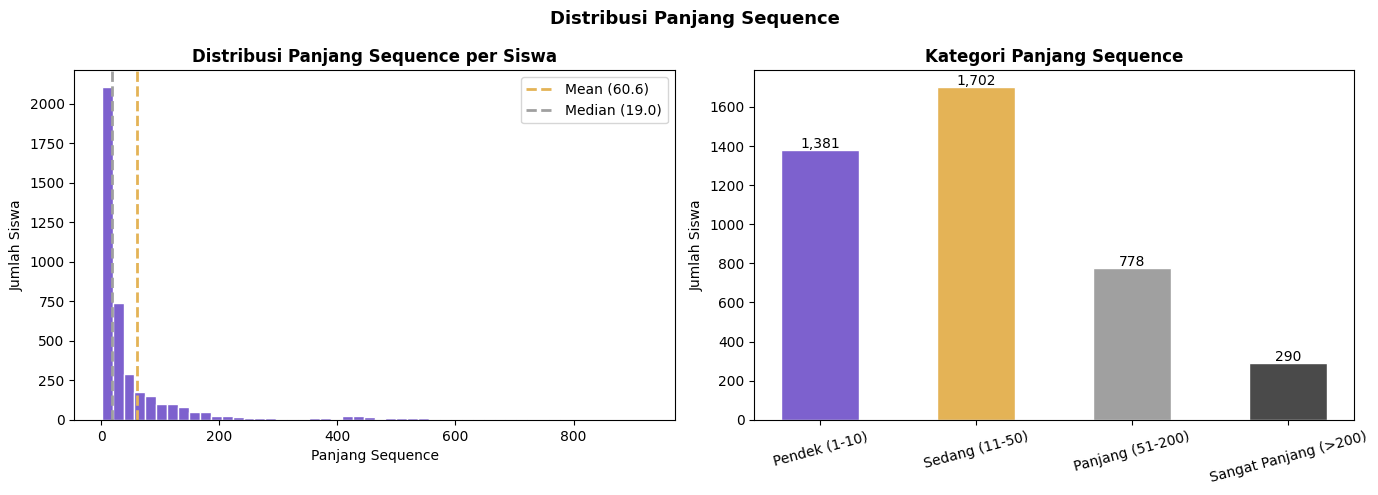

In [ ]:
# Statistik panjang sequence
print(f"\nStatistik Panjang Sequence per Siswa:")
print(seq_df['seq_length'].describe().round(2))

# Kategorisasi panjang sequence
seq_df['seq_category'] = seq_df['seq_length'].apply(
    lambda x: 'Pendek (1-10)'    if x <= 10  else
              'Sedang (11-50)'   if x <= 50  else
              'Panjang (51-200)' if x <= 200 else
              'Sangat Panjang (>200)'
)

seq_cat = seq_df['seq_category'].value_counts()
seq_pct = seq_df['seq_category'].value_counts(normalize=True) * 100

print(f"\nDistribusi Panjang Sequence:")
for cat in seq_cat.index:
    print(f"  {cat} : {seq_cat[cat]:,} ({seq_pct[cat]:.2f}%)")

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 — Histogram panjang sequence
axes[0].hist(
    seq_df['seq_length'],
    bins=50,
    color='#7d61ce',
    edgecolor='white'
)
axes[0].axvline(
    seq_df['seq_length'].mean(),
    color='#E4b356',
    linestyle='--',
    linewidth=2,
    label=f'Mean ({seq_df["seq_length"].mean():.1f})'
)
axes[0].axvline(
    seq_df['seq_length'].median(),
    color='#a0a0a0',
    linestyle='--',
    linewidth=2,
    label=f'Median ({seq_df["seq_length"].median():.1f})'
)
axes[0].set_title('Distribusi Panjang Sequence per Siswa', fontweight='bold')
axes[0].set_xlabel('Panjang Sequence')
axes[0].set_ylabel('Jumlah Siswa')
axes[0].legend()

# Plot 2 — Bar chart kategori sequence
order = ['Pendek (1-10)', 'Sedang (11-50)',
         'Panjang (51-200)', 'Sangat Panjang (>200)']
seq_cat_sorted = seq_cat.reindex(order)
bars = axes[1].bar(
    seq_cat_sorted.index,
    seq_cat_sorted.values,
    color=['#7d61ce', '#E4b356', '#a0a0a0', '#4a4a4a'],
    edgecolor='white',
    width=0.5
)
axes[1].set_title('Kategori Panjang Sequence', fontweight='bold')
axes[1].set_ylabel('Jumlah Siswa')
axes[1].tick_params(axis='x', rotation=15)
for bar in bars:
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 10,
        f'{bar.get_height():,}',
        ha='center', fontsize=10
    )

plt.suptitle('Distribusi Panjang Sequence',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Insight**

Analisis distribusi panjang sequence menunjukkan karakteristik yang sangat penting untuk pengembangan model Knowledge Tracing. Dari total 4.151 siswa, mayoritas siswa memiliki sequence yang pendek namun ada sebagian kecil siswa dengan sequence yang sangat panjang sehingga menarik nilai rata-rata jauh di atas median, terbukti dari median hanya 19 interaksi namun mean mencapai 60.56 interaksi.

Dari sisi kategorisasi, mayoritas siswa berada di kategori sedang yaitu 1.702 siswa atau 41% dengan panjang sequence 11 hingga 50 interaksi. Siswa dengan sequence pendek 1 hingga 10 interaksi sebanyak 1.381 siswa atau 33.27%, proporsi yang cukup besar dan perlu mendapat perhatian khusus karena sequence yang terlalu pendek berpotensi tidak cukup memberikan informasi bagi model untuk mempelajari pola penguasaan konsep siswa secara akurat. Siswa dengan sequence panjang 51 hingga 200 interaksi sebanyak 778 siswa atau 18.74%, dan yang sangat panjang lebih dari 200 interaksi sebanyak 290 siswa atau 6.99%.

Temuan yang paling krusial adalah nilai minimum sequence hanya 1 interaksi  siswa dengan sequence sepanjang ini hampir tidak memberikan informasi yang cukup untuk model melakukan prediksi.

## Analisis Behavior Siswa

Analisis behavior siswa dilakukan untuk memahami pola dan karakteristik cara siswa berinteraksi dengan soal selama proses pembelajaran. Analisis ini mencakup distribusi correctness rate per siswa, penggunaan hint per siswa, dan konsistensi performa siswa secara keseluruhan. Insight yang dihasilkan akan membantu mengidentifikasi kelompok siswa berdasarkan karakteristik belajarnya.


Statistik Correctness Rate per Siswa:
count    4151.00
mean       62.30
std        26.59
min         0.00
25%        49.60
50%        66.67
75%        80.95
max       100.00
Name: correct_rate, dtype: float64

Statistik Hint Rate per Siswa:
count    4151.00
mean        0.51
std         0.71
min         0.00
25%         0.00
50%         0.23
75%         0.70
max         6.00
Name: hint_rate, dtype: float64

Kategorisasi Siswa berdasarkan Correctness Rate:
  Sedang (50-75%) : 1,678 (40.42%)
  Tinggi (>75%) : 1,431 (34.47%)
  Rendah (<50%) : 1,042 (25.10%)


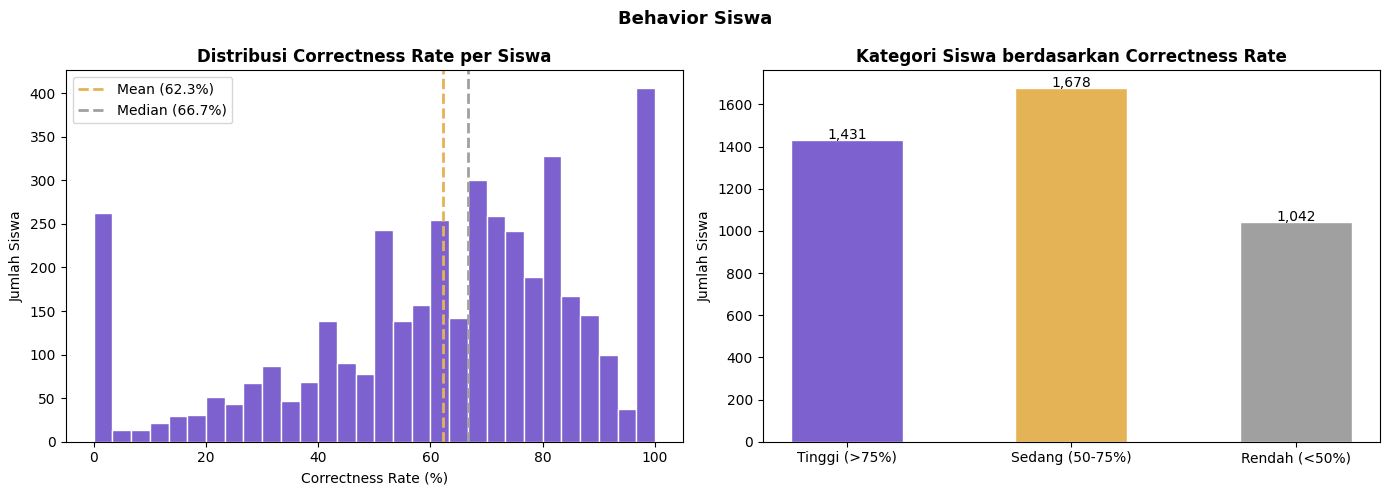

In [ ]:
# Hitung correctness rate per siswa dari df_filtered
student_stats = df_filtered.groupby('user_id').agg(
    total_interactions = ('correct', 'count'),
    total_correct      = ('correct', 'sum'),
    total_hint         = ('hint_count', 'sum'),
    avg_attempt        = ('attempt_count', 'mean')
).reset_index()

student_stats['correct_rate'] = (
    student_stats['total_correct'] /
    student_stats['total_interactions'] * 100
).round(2)

student_stats['hint_rate'] = (
    student_stats['total_hint'] /
    student_stats['total_interactions']
).round(2)

print(f"\nStatistik Correctness Rate per Siswa:")
print(student_stats['correct_rate'].describe().round(2))

print(f"\nStatistik Hint Rate per Siswa:")
print(student_stats['hint_rate'].describe().round(2))

# Kategorisasi siswa berdasarkan correctness rate
student_stats['student_category'] = student_stats['correct_rate'].apply(
    lambda x: 'Tinggi (>75%)'    if x > 75 else
              'Sedang (50-75%)'  if x >= 50 else
              'Rendah (<50%)'
)

stu_cat = student_stats['student_category'].value_counts()
stu_pct = student_stats['student_category'].value_counts(normalize=True) * 100

print(f"\nKategorisasi Siswa berdasarkan Correctness Rate:")
for cat in stu_cat.index:
    print(f"  {cat} : {stu_cat[cat]:,} ({stu_pct[cat]:.2f}%)")

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 — Distribusi correctness rate per siswa
axes[0].hist(
    student_stats['correct_rate'],
    bins=30,
    color='#7d61ce',
    edgecolor='white'
)
axes[0].axvline(
    student_stats['correct_rate'].mean(),
    color='#E4b356',
    linestyle='--',
    linewidth=2,
    label=f'Mean ({student_stats["correct_rate"].mean():.1f}%)'
)
axes[0].axvline(
    student_stats['correct_rate'].median(),
    color='#a0a0a0',
    linestyle='--',
    linewidth=2,
    label=f'Median ({student_stats["correct_rate"].median():.1f}%)'
)
axes[0].set_title('Distribusi Correctness Rate per Siswa', fontweight='bold')
axes[0].set_xlabel('Correctness Rate (%)')
axes[0].set_ylabel('Jumlah Siswa')
axes[0].legend()

# Plot 2 — Kategori siswa
order = ['Tinggi (>75%)', 'Sedang (50-75%)', 'Rendah (<50%)']
stu_cat_sorted = stu_cat.reindex(order)
bars = axes[1].bar(
    stu_cat_sorted.index,
    stu_cat_sorted.values,
    color=['#7d61ce', '#E4b356', '#a0a0a0'],
    edgecolor='white',
    width=0.5
)
axes[1].set_title('Kategori Siswa berdasarkan Correctness Rate',
                   fontweight='bold')
axes[1].set_ylabel('Jumlah Siswa')
for bar in bars:
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 5,
        f'{bar.get_height():,}',
        ha='center', fontsize=10
    )

plt.suptitle('Behavior Siswa',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Insight**

Dari sisi correctness rate per siswa, rata-rata siswa berhasil menjawab dengan benar sebesar 62.30% dari seluruh interaksinya dengan median 66.67%. Nilai minimum mencapai 0% dan maksimum 100% menunjukkan bahwa ada siswa yang tidak pernah berhasil menjawab dengan benar sama sekali, maupun siswa yang selalu menjawab dengan benar di setiap interaksinya.

Dari sisi kategorisasi, mayoritas siswa berada di kategori sedang yaitu 1.678 siswa atau 40.42% dengan correctness rate antara 50 hingga 75%. Siswa berkategori tinggi dengan correctness rate di atas 75% sebanyak 1.431 siswa atau 34.47%, dan siswa berkategori rendah dengan correctness rate di bawah 50% sebanyak 1.042 siswa atau 25.10%. Distribusi ini menunjukkan bahwa sebagian besar siswa memiliki pemahaman yang cukup namun masih ada seperempat siswa yang perlu mendapat perhatian lebih karena tingkat keberhasilan mereka masih di bawah 50%.

Dari sisi hint rate per siswa, rata-rata siswa menggunakan 0.51 hint per interaksi dengan median 0.23. Namun nilai maksimum mencapai 6.00 yang mengindikasikan ada siswa yang sangat bergantung pada hint dalam setiap interaksinya. Kombinasi antara correctness rate rendah dan hint rate tinggi pada kelompok siswa tertentu bisa menjadi indikator awal untuk analisis bias model pada Business Question kedua apakah model menunjukkan bias pada kelompok siswa dengan karakteristik belajar tertentu.

## Analisis Learning Progression

Analisis learning progression dilakukan untuk memahami bagaimana performa siswa berkembang seiring bertambahnya pengalaman mengerjakan soal. Analisis ini menggunakan kolom opportunity sebagai representasi urutan pertemuan siswa dengan suatu konsep, sehingga dapat dilihat apakah terdapat pola peningkatan penguasaan konsep secara temporal pada kelompok siswa secara keseluruhan.


Learning Curve (Opportunity 1-10):
 opportunity  total  correct_rate
           1  32868         59.44
           2  24518         67.04
           3  20596         68.36
           4  18845         70.62
           5  16923         69.40
           6  14313         69.45
           7  12420         68.45
           8  10760         69.75
           9   9688         68.70
          10   8601         68.56


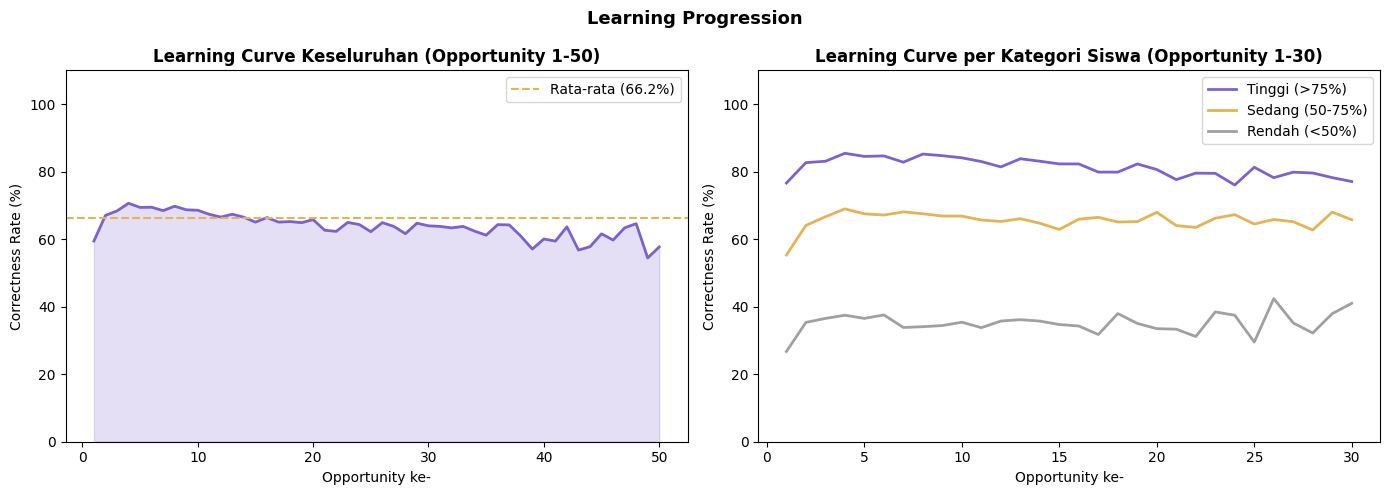

In [ ]:
# Hitung correctness rate per opportunity (learning curve)
lc = df_filtered[df_filtered['opportunity'] <= 50].groupby('opportunity').agg(
    total=('correct', 'count'),
    correct=('correct', 'sum')
).reset_index()
lc['correct_rate'] = (lc['correct'] / lc['total'] * 100).round(2)

print(f"\nLearning Curve (Opportunity 1-10):")
print(lc.head(10)[['opportunity', 'total', 'correct_rate']].to_string(index=False))

# Hitung correctness rate per opportunity per kategori siswa
student_cat = student_stats[['user_id', 'student_category']]
df_with_cat = df_filtered.merge(student_cat, on='user_id', how='left')

lc_by_cat = df_with_cat[df_with_cat['opportunity'] <= 30].groupby(
    ['opportunity', 'student_category']
).agg(
    total=('correct', 'count'),
    correct=('correct', 'sum')
).reset_index()
lc_by_cat['correct_rate'] = (
    lc_by_cat['correct'] / lc_by_cat['total'] * 100
).round(2)

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 — Learning curve keseluruhan
axes[0].plot(
    lc['opportunity'],
    lc['correct_rate'],
    color='#7d61ce',
    linewidth=2
)
axes[0].fill_between(
    lc['opportunity'],
    lc['correct_rate'],
    alpha=0.2,
    color='#7d61ce'
)
axes[0].axhline(
    y=df_filtered['correct'].mean() * 100,
    color='#E4b356',
    linestyle='--',
    linewidth=1.5,
    label=f'Rata-rata ({df_filtered["correct"].mean()*100:.1f}%)'
)
axes[0].set_title('Learning Curve Keseluruhan (Opportunity 1-50)',
                   fontweight='bold')
axes[0].set_xlabel('Opportunity ke-')
axes[0].set_ylabel('Correctness Rate (%)')
axes[0].set_ylim(0, 110)
axes[0].legend()

# Plot 2 — Learning curve per kategori siswa
colors = {
    'Tinggi (>75%)'  : '#7d61ce',
    'Sedang (50-75%)': '#E4b356',
    'Rendah (<50%)'  : '#a0a0a0'
}
for cat, color in colors.items():
    data = lc_by_cat[lc_by_cat['student_category'] == cat]
    axes[1].plot(
        data['opportunity'],
        data['correct_rate'],
        color=color,
        linewidth=2,
        label=cat
    )
axes[1].set_title('Learning Curve per Kategori Siswa (Opportunity 1-30)',
                   fontweight='bold')
axes[1].set_xlabel('Opportunity ke-')
axes[1].set_ylabel('Correctness Rate (%)')
axes[1].set_ylim(0, 110)
axes[1].legend()

plt.suptitle('Learning Progression',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Insight**

Pada opportunity pertama, correctness rate berada di 59.44% — nilai terendah dalam keseluruhan learning curve. Ini sangat masuk akal karena siswa baru pertama kali bertemu dengan suatu konsep sehingga tingkat keberhasilannya masih rendah. Selain itu, ditemukan lonjakan peningkatan yang signifikan terjadi antara opportunity pertama dan kedua — correctness rate naik dari 59.44% menjadi 67.04% atau meningkat sekitar 7.6 poin persentase hanya dalam satu kesempatan tambahan. Ini mengindikasikan bahwa pengulangan pertama memberikan dampak pembelajaran yang paling besar dibandingkan pengulangan-pengulangan berikutnya.

Setelah opportunity kedua, correctness rate cenderung stabil di kisaran 68-71% tanpa peningkatan yang signifikan hingga opportunity ke-10. Pola plateau ini mengindikasikan bahwa sebagian besar siswa mencapai tingkat penguasaan yang relatif stabil setelah beberapa kali pertemuan dengan suatu konsep. Namun stabilnya correctness rate di angka tersebut juga bisa mengindikasikan adanya kelompok siswa yang memang mengalami kesulitan permanen pada konsep tertentu sehingga tidak menunjukkan peningkatan meskipun sudah berulang kali mengerjakan soal yang sama.

Temuan sangat relevan untuk pengembangan model DKT karena menunjukkan bahwa interaksi awal siswa dengan suatu konsep adalah yang paling informatif untuk memprediksi pola penguasaan selanjutnya. Menjadi insight yang bisa digunakan AI Engineer untuk menentukan strategi pembobotan sequence dalam model.

## Insight Summary untuk Model

**Data Overview**

Setelah seluruh proses EDA selesai, dataset akhir terdiri dari 251.405 interaksi bersih dengan 4.151 siswa unik, 136 unique skill_id yang terdiri dari 93 single skill dan 43 composite skill, serta 101 konsep matematika berdasarkan skill_name. Overall correctness rate berada di 66.17%.

**Temuan Kritis**

**1. Hint Contamination**

Sebanyak 13.82% interaksi dengan label correct=0 berasal dari penggunaan hint, bukan kegagalan murni. Kondisi ini perlu dipertimbangkan oleh AI Engineer dalam interpretasi label negatif pada model.

**2. Multi-Skill Tags**

Sebanyak 17.83% interaksi memiliki composite skill_id dengan multiple tag. Menggunakan Option B yaitu keep as composite skill sehingga total unique concept_id yang akan digunakan model adalah 136.

**3. Distribusi Sequence**

Median panjang sequence hanya 19 interaksi dengan 33.27% siswa memiliki sequence pendek antara 1 hingga 10 interaksi. Perlu ada penetapan minimum sequence length sebelum training model dimulai.

**4. Variasi Kesulitan Skill**

Terdapat variasi correctness rate yang sangat besar antar skill dari 95% pada skill termudah hingga 14.04% pada skill tersulit dengan jumlah interaksi yang representatif. Model perlu mampu menangani variasi kesulitan yang signifikan ini.

**5. Learning Progression**

Lonjakan peningkatan correctness rate terbesar terjadi antara opportunity pertama dan kedua yaitu sebesar 7.6 poin persentase. Setelah itu correctness rate cenderung stabil di kisaran 68-71%. Ini mengindikasikan bahwa interaksi awal siswa dengan suatu konsep adalah yang paling informatif untuk prediksi model.

**Insight**
Berdasarkan hasil EDA, beberapa hal yang perlu diperhatikan AI Engineer dalam pengembangan model adalah sebagai berikut. Parameter num_concepts pada model DKT perlu disetel ke 136 sesuai jumlah unique skill_id. Minimum sequence length perlu didiskusikan bersama.  Kolom hint_count berpotensi dijadikan fitur tambahan sebagai indikator kesulitan siswa. Perlu diwaspadai potensi bias model pada siswa dengan sequence pendek dan hint rate tinggi.